# Introduction

This Jupyter Notebook is dedicated to the comprehensive exploration, preprocessing, and transformation of a glass formation dataset originally derived from the SciGlass database and curated by Daniel Cassar. The dataset initially consists of over 72,000 samples, encompassing chemical compositions that result in glassy, crystalline, or intermediate structures. In its raw form, the dataset contains 319 features: 317 quantitative variables corresponding to inorganic compound fractions, a unique identification code (`Kod`), and the categorical target variable (`GF`), which represents the glass-forming ability.

This notebook performs essential (pre)processing steps, including data cleaning, consistency checks, identification and resolution of conflicting records, removal of duplicated entries, and exclusion of invalid or incomplete samples.

The workflow transforms the original chemical compositions into a high-dimensional feature space using the `glasspy` library. This process generates a rich set of elemental descriptors and physicochemical properties, computed both as mass-weighted averages and as absolute values. These features encode information related to atomic size, electronegativity, bonding tendencies, and other fundamental properties relevant to glass formation.

Given the resulting high dimensionality (reaching several thousand columns), this notebook adopts a Dynamic MultiIndex strategy to improve data organization and interpretability. This hierarchical structure groups features into five functional categories:

* `compounds`: The original raw chemical components (oxide or compound fractions);
* `elements`: Calculated elemental concentrations derived from the compound composition;
* `weighted_properties`: Mass-weighted average physical and chemical properties of the elements;
* `absolute_properties`: Absolute (summed) elemental properties of the constituent elements;
* `metadata`: Number of distinct chemical elements/compounds present in each sample;
* `sample_id`: Unique identifier assigned to each composition;
* `target`: glass-forming classification.

## Imports

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statistics as st
import seaborn as sns
from glasspy.chemistry.featurizer import physchem_featurizer, _prop
from glasspy.chemistry import to_element_array
import pandas as pd
from itertools import product

## Data Loading

In [2]:
df = pd.read_csv("../data/raw/GF_data_compound.zip", sep = "\t")
display(df)

,ZnO,Sb2O3,Na2O,MoO3,Bi2O3,TeO2,V2O5,P2O5,B2O3,CaO,...,BiNbO4,Se4I,GeTe4.3,GaTe3,ZnI2,Na2Se,MgS,AsTe3,Kod,GF
0,0.00,0.00,0.0,0.0,0.00,0.00,0.0,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21883,Clear glass
1,0.00,0.00,0.0,0.0,0.00,88.55,0.0,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21472,Clear glass
2,0.00,0.00,0.0,0.0,0.00,0.00,25.4,0.00,49.35,25.25,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22665,Glass and crystal
3,0.00,0.00,0.0,0.0,89.70,0.00,0.0,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23009,Glass and crystal
4,0.00,0.00,0.0,0.0,0.00,0.00,0.0,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24639,Crystal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72121,0.00,49.96,0.0,0.0,0.00,29.78,0.0,0.00,20.26,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22220,Crystal
72122,0.00,0.00,0.0,0.0,0.00,10.35,0.0,0.00,39.97,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22603,Crystal
72123,20.28,0.00,0.0,0.0,0.00,0.00,0.0,30.02,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33008,Glass
72124,0.00,0.00,0.0,0.0,48.89,0.00,0.0,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22175,Clear glass


In [3]:
df.head(15)

,ZnO,Sb2O3,Na2O,MoO3,Bi2O3,TeO2,V2O5,P2O5,B2O3,CaO,...,BiNbO4,Se4I,GeTe4.3,GaTe3,ZnI2,Na2Se,MgS,AsTe3,Kod,GF
0,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21883,Clear glass
1,0.0,0.0,0.00,0.0,0.0,88.55,0.00,0.0,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21472,Clear glass
2,0.0,0.0,0.00,0.0,0.0,0.00,25.40,0.0,49.35,25.25,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22665,Glass and crystal
3,0.0,0.0,0.00,0.0,89.7,0.00,0.00,0.0,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23009,Glass and crystal
4,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24639,Crystal
5,0.0,0.0,0.00,0.0,0.0,0.00,76.84,4.6,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22412,Glass
6,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28339,Glass
7,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.0,34.65,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23202,Glass
8,0.0,0.0,0.00,0.0,0.0,0.00,0.00,50.0,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23360,Imperfect melt
9,0.0,0.0,12.60,0.0,0.0,0.00,0.00,0.0,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23688,Unmelted


In [4]:
_prop

array(['atomic_number', 'atomic_radius', 'atomic_radius_rahm',
       'atomic_volume', 'atomic_weight', 'boiling_point', 'c6', 'c6_gb',
       'covalent_radius_bragg', 'covalent_radius_cordero',
       'covalent_radius_pyykko', 'covalent_radius_pyykko_double',
       'covalent_radius_pyykko_triple', 'covalent_radius_slater',
       'density', 'dipole_polarizability', 'electron_affinity',
       'electrons', 'evaporation_heat', 'fusion_heat', 'gas_basicity',
       'glawe_number', 'heat_of_formation', 'lattice_constant',
       'mass_number', 'melting_point', 'mendeleev_number',
       'metallic_radius', 'metallic_radius_c12', 'neutrons',
       'pettifor_number', 'proton_affinity', 'protons', 'specific_heat',
       'thermal_conductivity', 'vdw_radius', 'vdw_radius_alvarez',
       'vdw_radius_batsanov', 'vdw_radius_bondi', 'vdw_radius_dreiding',
       'vdw_radius_mm3', 'vdw_radius_rt', 'vdw_radius_truhlar',
       'vdw_radius_uff', 'en_Allen', 'en_Allred_Rochow',
       'en_Cottrell_

## Functions

In [5]:
# from glasspy.chemistry.featurizer import physchem_featurizer, _prop
# from glasspy.chemistry import to_element_array
# import pandas as pd
# from itertools import product

def featurizer_GF(df, compositions_columns):
    """
    Generate physicochemical features for chemical compositions using predefined elemental properties.

    Parameters:
    -----------
    df : pd.DataFrame
        The original dataframe that contains 'Kod' and 'GF' columns, among others.
    compositions_columns : pd.DataFrame
        A dataframe containing the composition information for each sample (compounds fractions).

    Returns:
    --------
    df_feature_engineering : pd.DataFrame
        A dataframe containing the original composition columns, the newly computed
        physicochemical features, and the original 'Kod' and 'GF' columns.
    """

    Kod_column = df.loc[:,'Kod']
    GF_column = df.loc[:,'GF']

    elements = to_element_array(compositions_columns, output_element_cols="default").cols

    aggregate_functions = ['sum', 'mean', 'min', 'max', 'std']

    eliminar = {'proton_affinity', 'metallic_radius',
    'vdw_radius_bondi', 'c6_gb', 'ElectronAffinity', 'evaporation_heat',
    'en_Pauling', 'fusion_heat', 'thermal_conductivity', 'c6', 'n_ws^third',
    'BulkModulus', 'specific_heat', 'vdw_radius_dreiding', 'phi',
    'covalent_radius_bragg', 'covalent_radius_slater', 'hardness',
    'vdw_radius_batsanov', 'vdw_radius_truhlar', 'SecondIonizationEnergy',
    'metallic_radius_c12', 'MiracleRadius', 'gas_basicity', 'vdw_radius_rt',
    'covalent_radius_pyykko_double', 'en_Allen', 'electron_affinity',
    'covalent_radius_pyykko_triple', 'ShearModulus', 'en_Mulliken',
    'lattice_constant'}

    all_features = [
        (p, a) for p, a in product(_prop, aggregate_functions) if p not in eliminar
    ]

    feat_array, cols = physchem_featurizer(
        compositions_columns,
        elemental_features=elements,
        weighted_features=all_features,
        absolute_features=all_features,
    )

    df_feature_engineering_columns = pd.DataFrame(feat_array, columns=cols)

    df_feature_engineering = df

    df_feature_engineering = pd.concat([compositions_columns, df_feature_engineering_columns, Kod_column, GF_column], axis=1)

    return df_feature_engineering


################################################################################################################################


# import pandas as pd

def apply_smart_multiindex(df_engineered, original_compounds_df):
    """
    Dynamically creates a MultiIndex for the DataFrame, correctly handling 
    overlapping names between compounds and elements by using positional logic.
    """
    
    num_compounds = len(original_compounds_df)
    
    named_families = []
    
    for i, col in enumerate(df_engineered):
        # The first columns are ALWAYS the original compounds
        if i < num_compounds:
            family = 'compounds'
        
        # Identification by keyword/prefix for the remaining columns
        elif col == 'Kod':
            family = 'sample_id'
        elif col == 'GF':
            family = 'target'
        elif col.startswith('W|'):
            family = 'weighted_properties'
        elif col.startswith('A|'):
            family = 'absolute_properties'
        
        # Anything else after the compound block that isn't a property 
        # is a calculated element concentration.
        else:
            family = 'elements'
            
        named_families.append((family, col))

    # Create the multi-indexed copy
    df_multi = df_engineered.copy()
    df_multi.columns = pd.MultiIndex.from_tuples(named_families)
    return df_multi


################################################################################################################################


# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns

def plot_bar_with_fraction(data, title='', xlabel='', ylabel='', log_scale=True, 
                          palette='viridis', figsize=(16, 9), dpi=300, 
                          rotation=90, font_scale=1.2, top_n=None, split_plots=False, 
                          n_splits=4, show_values=False, grid_style='darkgrid',
                          xlabel_fontsize=12, xtick_fontsize=None, 
                          title_fontsize=18, suptitle_fontsize=20):
    """
    Creates a bar plot with a secondary axis showing fractions.
    
    Parameters:
    -----------
    data : pd.Series
        Data to be plotted (values and indexes will be used)
    title : str, optional
        Plot title
    xlabel : str, optional
        X-axis label
    ylabel : str, optional
        Primary y-axis label
    log_scale : bool, default=True
        If True, uses logarithmic scale on y-axis
    palette : str, default='viridis'
        Seaborn color palette
    figsize : tuple, default=(16, 9)
        Figure size
    dpi : int, default=300
        Figure resolution
    rotation : int, default=90
        Rotation of x-axis labels
    font_scale : float, default=1.2
        Base font scale
    top_n : int, optional
        If specified, plots only the top_n items
    split_plots : bool, default=False
        If True, splits the plot into subplots
    n_splits : int, default=4
        Number of splits if split_plots=True
    show_values : bool, default=False
        If True, shows values on bars
    grid_style : str, default='darkgrid'
        Seaborn grid style
    xlabel_fontsize : int, default=12
        Font size for x-axis label
    xtick_fontsize : int, optional
        Font size for x-axis tick labels. If None, scales with font_scale
    title_fontsize : int, default=18
        Font size for the main title
    suptitle_fontsize : int, default=20
        Font size for the super title (when using split_plots)
    
    Returns:
    --------
    matplotlib.figure.Figure
        Created figure
    """
    sns.set(style=grid_style, font_scale=font_scale)
    
    # Set default x-tick font size if not specified
    if xtick_fontsize is None:
        xtick_fontsize = 10 * font_scale
    
    # Process data
    if top_n is not None:
        data = data.nlargest(top_n).sort_values(ascending=False)
    fraction = data / data.sum()
    
    if split_plots:
        # Create split subplots
        split_data = np.array_split(data, n_splits)
        split_percent = np.array_split(fraction, n_splits)
        
        fig, axes = plt.subplots(2, 2, figsize=figsize, dpi=dpi) if n_splits == 4 else plt.subplots(1, n_splits, figsize=figsize, dpi=dpi)
        fig.suptitle(title, fontsize=suptitle_fontsize)
        axes = axes.flatten()
        
        quartile_names = ["1st Quartile", "2nd Quartile", "3rd Quartile", "4th Quartile"]
        yticks = [10**i for i in range(0, 6)] if log_scale else None
        ylim = (1, 10**5) if log_scale else None
        
        for i, (count_subset, percent_subset) in enumerate(zip(split_data, split_percent)):
            ax1 = axes[i]
            
            barplot = sns.barplot(
                x=count_subset.index,
                y=count_subset.values,
                hue=count_subset.index,
                palette=palette,
                ax=ax1,
                dodge=False,
                legend=False
            )
            
            ax1.set_title(f'{quartile_names[i]}\n', fontsize=title_fontsize-2)  # Slightly smaller for subplot titles
            ax1.set_xlabel('', fontsize=xlabel_fontsize)
            ax1.set_ylabel(ylabel if i%2==0 else '', fontsize=12)
            
            if log_scale:
                ax1.set_yscale('log')
                ax1.set_yticks(yticks)
                ax1.set_ylim(ylim)
            
            ax1.tick_params(axis='x', labelsize=xtick_fontsize, rotation=rotation)
            ax1.grid(True, which='major', axis='y', linewidth=2, color='white')
            if log_scale:
                ax1.grid(True, which='minor', axis='y', linewidth=1, linestyle='--', alpha=0.8, color='white')
            ax1.set_axisbelow(False)
            
            if show_values:
                for j, (count, pct) in enumerate(zip(count_subset.values, percent_subset.values)):
                    bar = barplot.patches[j]
                    height = bar.get_height()
                    x = bar.get_x() + bar.get_width() / 2
                    ax1.text(
                        x, height * 1.1, 
                        f"{count}\n({pct:.3f})", 
                        ha='center', va='bottom', fontsize=10
                    )
            
            ax2 = ax1.twinx()
            ax2.set_ylabel('Fraction of Total', rotation=270, labelpad=20, fontsize=12)
            if log_scale:
                ax2.set_yscale('log')
                ax2.set_yticks(yticks)
                ax2.set_ylim(ylim)
                ax2.set_yticklabels([f"{(y / data.sum()):.4f}" for y in yticks])
            ax2.grid(False)
        
        plt.tight_layout()
        return fig
    
    else:
        # Create single plot
        fig, ax1 = plt.subplots(figsize=figsize, dpi=dpi)
        
        barplot = sns.barplot(
            x=data.index,
            y=data.values,
            hue=data.index,
            palette=palette,
            ax=ax1,
            dodge=False,
            legend=False
        )
        
        ax1.set_title(title, fontsize=title_fontsize)
        ax1.set_xlabel(xlabel, fontsize=xlabel_fontsize)
        ax1.set_ylabel(ylabel)
        
        if log_scale:
            yticks = [10**i for i in range(0, 6)]
            ax1.set_yscale('log')
            ax1.set_yticks(yticks)
        
        ax1.tick_params(axis='x', labelsize=xtick_fontsize, rotation=rotation)
        ax1.grid(True, axis='y', linewidth=2)
        ax1.set_axisbelow(False)
        
        if show_values:
            for i, (count, pct) in enumerate(zip(data.values, fraction.values)):
                bar = barplot.patches[i]
                height = bar.get_height()
                x = bar.get_x() + bar.get_width() / 2
                ax1.text(x, height * 1, f"{count}\n({pct:.3f})", ha='center', va='bottom', fontsize=12)
        
        ax2 = ax1.twinx()
        ax2.set_ylabel('Fraction of Total', rotation=270, labelpad=20)
        if log_scale:
            ax2.set_yscale('log')
            ax2.set_yticks(yticks)
            ax2.set_ylim(ax1.get_ylim())
            ax2.set_yticklabels([f"{(y / data.sum()):.3f}" for y in yticks], rotation=0)
        ax2.grid(False)
        
        plt.tight_layout()
        return fig


def plot_compound_distribution(compound_counts, title='', figsize=(16, 10), palette='viridis', 
                              font_scale=1.2, show_values=True, grid_style='darkgrid',
                              xlabel_fontsize=12, xtick_fontsize=None, rotation=0,
                              title_fontsize=18):
    """
    Plots the distribution of number of compounds per sample.
    
    Parameters:
    -----------
    compound_counts : pd.Series
        Count of samples by number of compounds
    title : str, optional
        Plot title
    figsize : tuple, default=(16, 10)
        Figure size
    palette : str, default='viridis'
        Seaborn color palette
    font_scale : float, default=1.2
        Base font scale
    show_values : bool, default=True
        If True, shows values on bars
    grid_style : str, default='darkgrid'
        Seaborn grid style
    xlabel_fontsize : int, default=12
        Font size for x-axis label
    xtick_fontsize : int, optional
        Font size for x-axis tick labels. If None, scales with font_scale
    rotation : int, default=0
        Rotation of x-axis labels
    title_fontsize : int, default=18
        Font size for the plot title
    
    Returns:
    --------
    matplotlib.figure.Figure
        Created figure
    """
    sns.set(style=grid_style, font_scale=font_scale)
    
    # Set default x-tick font size if not specified
    if xtick_fontsize is None:
        xtick_fontsize = 10 * font_scale
    
    fig, ax1 = plt.subplots(figsize=figsize)
    
    percent_compounds = compound_counts / compound_counts.sum()
    
    barplot = sns.barplot(
        x=compound_counts.index,
        y=compound_counts.values,
        hue=compound_counts.index,
        palette=palette,
        ax=ax1,
        dodge=False,
        legend=False
    )
    
    ax1.set_title(title, fontsize=title_fontsize)
    #ax1.set_xlabel('Number of Compounds Present in Composition', fontsize=xlabel_fontsize)
    ax1.set_xlabel('')
    ax1.set_ylabel('Number of Samples')
    ax1.set_yscale('log')
    yticks = [10**i for i in range(0, 6)]
    ax1.set_yticks(yticks)
    ax1.tick_params(axis='x', labelsize=xtick_fontsize, rotation=rotation)
    ax1.set_axisbelow(False)
    ax1.grid(True, axis='y', linewidth=2)
    
    if show_values:
        for i, (count, pct) in enumerate(zip(compound_counts.values, percent_compounds.values)):
            bar = barplot.patches[i]
            height = bar.get_height()
            x = bar.get_x() + bar.get_width() / 2
            ax1.text(x, height * 1, f"{count}\n({pct:.3f})", ha='center', va='bottom', fontsize=11)
    
    ax2 = ax1.twinx()
    ax2.set_ylabel('Fraction of Total', rotation=270, labelpad=20)
    ax2.set_yscale('log')
    ax2.set_yticks(yticks)
    ax2.set_ylim(ax1.get_ylim())
    ax2.set_yticklabels([f"{(y / compound_counts.sum()):.3f}" for y in yticks], rotation=0)
    ax2.grid(False)
    
    plt.tight_layout()
    return fig


##################################################################################################################################


def optimize_dtypes(df):
    """
    Optimizes data types by downcasting floats and integers to save space.
    """
    df_optimized = df.copy()
    
    # Downcast floats: float64 -> float32
    float_cols = df_optimized.select_dtypes(include=['float64']).columns
    df_optimized[float_cols] = df_optimized[float_cols].astype('float32')
    
    # Downcast integers: int64 -> int32 or int16
    int_cols = df_optimized.select_dtypes(include=['int64']).columns
    for col in int_cols:
        df_optimized[col] = pd.to_numeric(df_optimized[col], downcast='integer')
        
    return df_optimized

## Constants

In [6]:
first_palette_name = "icefire" #flare
main_palette_name = "crest"
unimodal_palette_name = "mako"

RANDOM_SEED = 0
TEST_SIZE_SPLIT = 0.1

# Data Pre-Processing
## Negative values 

In [7]:
Kod_column = df.loc[:,'Kod']
GF_column = df.loc[:,'GF']
df_pre_processed = df.copy()
df_pre_processed = df_pre_processed.drop(['Kod', 'GF'], axis=1) # drop the code attribute

In [8]:
print(f"Number of examples with at least one negative value: {len(df_pre_processed[(df_pre_processed.select_dtypes(include='number') < 0).any(axis=1)])}\n"
      f"Number of negative values: {(df_pre_processed < 0).sum().sum()}")

pd.set_option('display.max_rows', None)  # show all rows 
pd.set_option('display.max_columns', None) # show all columns

display(round(df_pre_processed.describe(), 2)) # show descriptive statistics of the dataset

pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

Number of examples with at least one negative value: 474
Number of negative values: 474


,ZnO,Sb2O3,Na2O,MoO3,Bi2O3,TeO2,V2O5,P2O5,B2O3,CaO,Nb2O5,Ge,Se,Ag,BaO,K2O,SrO,Li2O,La2O3,MgO,ThO2,Al2O3,BeO,ZrO2,TiO2,Ta2O5,WO3,Tl2O,CdO,PbO,In2O3,SnO2,Ga2O3,Cs2O,Rb2O,Y2O3,Sc2O3,SiO2,GeO2,UO2,LaF3,ZrF4,PbF2,Ag2O,MnO,Cu2O,HfO2,AlN,CrO3,Nd2O3,AlF3,Fe2O3,Cr2O3,BaF2,InF3,MgF2,PbCl2,ZnCl2,PbI2,Fe3O4,CeO2,CuO,ThF4,ZnF2,YbF3,YF3,As2O3,Dy2O3,NiO,CoO,LiCl,SrF2,CaF2,Sm2O3,BeF2,KF,VO2,NaF,HgO,MnO2,As2O5,SO3,Na2S,MnF2,KCl,ThCl4,NaCl,BiCl3,CdCl2,PbBr2,CuCl,BaCl2,CsI,BaI2,CuI,ZnBr2,KBr,CdBr2,BaBr2,MgBr2,CaBr2,SrBr2,MnBr2,CoBr2,FeBr2,BiF3,CsF,AgF,AgI,FeO,TmF3,NdF3,TlBr,TlI,GdF3,SnO,SnCl2,Sb,Mn2O3,DyF3,HoF3,ErF3,Sb2O5,Gd2O3,SnF2,Er2O3,Yb2O3,Co2O3,Ni2O3,NiSO4,CdF2,GaF3,UF4,Ca3N2,P3N5,Li3N,FeF3,FeF2,CdI2,KI,PrF3,SmF3,CeF3,EuF3,TbF3,AgBr,AgCl,CrF3,Li2SO4,NaI,SeO3,Pr2O3,S,Ga,As,Cu,EuS,Ga2S3,GeS2,As2Se3,GeTe,I,B,Ni,P,Tl,Bi,BaS,La2S3,Te,Al,Ag2S,GeS,Cl,ZnS,CdS,CdTe,Sb2Se3,GeSe2,Si,Cd,Br,MnS,ZnSe,GeSe3,Tl2S,Sb2S3,As2S3,Cu2Se,SnS,PbS,PbSe,GeSe,Li2S,In,MnCl2,HgTe,Hg,Sn,CaS,SrS,Fe,CdSe,Pb,B2S3,P2S5,SnSe,SnSe2,AsI3,SbI3,BiI3,Fe2S3O12,ZnSO4,K2SO4,AsSe,H2S,SbO2,Ag2Se,HgSe,O,LiI,SiS2,LiBr,Ag4SSe,SnTe,NaPO3,CuPO3,Cu2WO4,Cu3PO4,CuBr,Cu2MoO4,AgPO3,Ag2MoO4,HgI2,As2Te3,BaHPO4,BaP2O6,NbO2F,LiF,BPO4,Sb2Te3,TeI,In2S3,K2S,ZrS2,Ga2Se3,In2Se3,CsBr,Zn,Nd2S3,Eu,BaB2O4,BaGeO3,Al2S3,Na2SO4,PbP2O6,ZnP2O6,Na2B4O7,MgSO4,Bi2S3,AlP3O9,K2NbOF5,Li3PO4,Al2Y2O6,PbTe,CsCl,Li2MoO4,Li2WO4,Na2MoO4,Na2WO4,Ag2Te,Bi2Se3,BaPO3F,ZnTe,HgS,AlPO4,Ho2O3,Li2B4O7,Tl2Se,SrB2O4,Pr6O11,Tb4O7,ErCl3,GdCl3,TmCl3,HoCl3,NdCl3,KPO3,SrSO4,ErPO4,SbP3O9,ScP3O9,HfF4,KHSO4,KBO2,GeTe4,In2Te6,Ga2Te3,KAsO3,Na4As2O7,Co3O4,Er2S3,LiHSO4,NaHSO4,SrCl2,TaO2F,Lu2O3,AsTe,P2Se5,BiNbO4,Se4I,GeTe4.3,GaTe3,ZnI2,Na2Se,MgS,AsTe3
count,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.0,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.0,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.0,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.00,72126.0

In [9]:
num_negative_values = round(df_pre_processed.describe(), 2).loc['min',:][round(df_pre_processed.describe(), 2).loc['min',:] < 0].nunique()
negative_values = sorted(round(df_pre_processed.describe(), 2).loc['min',:][round(df_pre_processed.describe(), 2).loc['min',:] < 0].unique())

print(f"The minimum value of the atomic fraction is: {round(df_pre_processed.describe(), 2).loc['min',:].min()}\n"
      f"The maximum value of the atomic fraction is: {round(df_pre_processed.describe(), 2).loc['max', :].max()}\n\n"
      f"There are {num_negative_values} possible negative values: {negative_values}")

The minimum value of the atomic fraction is: -1.33
The maximum value of the atomic fraction is: 101.0

There are 29 possible negative values: [np.float64(-1.33), np.float64(-1.3), np.float64(-1.27), np.float64(-1.19), np.float64(-1.0), np.float64(-0.8), np.float64(-0.7), np.float64(-0.64), np.float64(-0.6), np.float64(-0.5), np.float64(-0.47), np.float64(-0.46), np.float64(-0.43), np.float64(-0.42), np.float64(-0.4), np.float64(-0.38), np.float64(-0.3), np.float64(-0.28), np.float64(-0.27), np.float64(-0.2), np.float64(-0.17), np.float64(-0.16), np.float64(-0.15), np.float64(-0.13), np.float64(-0.11), np.float64(-0.1), np.float64(-0.08), np.float64(-0.06), np.float64(-0.03)]


In [10]:
df_pre_processed[df_pre_processed < 0] = 0 # negative numbers are equal to zero

df_pre_processed = df_pre_processed.div(df_pre_processed.sum(axis=1), axis=0) # normalize the values ​​of each row

print("Number of negative values:", ((df_pre_processed < 0).sum().sum()))

print("Number of examples that the sum of features doesn't result in 1", (round(df_pre_processed.sum(axis=1), 5) != 1).sum())

df_pre_processed = pd.concat([df_pre_processed, Kod_column, GF_column], axis=1) # add the 'GF' column back to the dataset

Number of negative values: 0
Number of examples that the sum of features doesn't result in 1 0


# Featurizer: Feature Engineering

In [11]:
compositions_columns = df_pre_processed.iloc[:,:-2]

df_feature_engineering = featurizer_GF(df_pre_processed, compositions_columns)

display(df_feature_engineering)

,ZnO,Sb2O3,Na2O,MoO3,Bi2O3,TeO2,V2O5,P2O5,B2O3,CaO,...,A|NsValence|min,A|NsValence|max,A|NsValence|std,A|SpaceGroupNumber|sum,A|SpaceGroupNumber|mean,A|SpaceGroupNumber|min,A|SpaceGroupNumber|max,A|SpaceGroupNumber|std,Kod,GF
0,0.0000,0.0000,0.0,0.0,0.0000,0.0000,0.000,0.0000,0.0000,0.0000,...,2.0,2.0,0.000000,462.0,154.000000,12.0,225.0,100.409163,21883,Clear glass
1,0.0000,0.0000,0.0,0.0,0.0000,0.8855,0.000,0.0000,0.0000,0.0000,...,2.0,2.0,0.000000,389.0,129.666667,12.0,225.0,88.379233,21472,Clear glass
2,0.0000,0.0000,0.0,0.0,0.0000,0.0000,0.254,0.0000,0.4935,0.2525,...,2.0,2.0,0.000000,632.0,158.000000,12.0,229.0,87.906200,22665,Glass and crystal
3,0.0000,0.0000,0.0,0.0,0.8970,0.0000,0.000,0.0000,0.0000,0.0000,...,2.0,2.0,0.000000,218.0,72.666667,12.0,194.0,85.795623,23009,Glass and crystal
4,0.0000,0.0000,0.0,0.0,0.0000,0.0000,0.000,0.0000,0.0000,0.0000,...,2.0,2.0,0.000000,689.0,172.250000,12.0,227.0,92.523983,24639,Crystal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72121,0.0000,0.4996,0.0,0.0,0.0000,0.2978,0.000,0.0000,0.2026,0.0000,...,2.0,2.0,0.000000,496.0,124.000000,12.0,166.0,64.915329,22220,Crystal
72122,0.0000,0.0000,0.0,0.0,0.0000,0.1035,0.000,0.0000,0.3997,0.0000,...,2.0,2.0,0.000000,559.0,139.750000,12.0,229.0,79.253943,22603,Crystal
72123,0.2028,0.0000,0.0,0.0,0.0000,0.0000,0.000,0.3002,0.0000,0.0000,...,2.0,2.0,0.000000,437.0,109.250000,2.0,229.0,103.056720,33008,Glass
72124,0.0000,0.0000,0.0,0.0,0.4889,0.0000,0.000,0.0000,0.0000,0.0000,...,2.0,2.0,0.000000,443.0,110.750000,12.0,225.0,99.356366,22175,Clear glass


In [12]:
for i in df_feature_engineering.columns:
    print(i, end=', ')

ZnO, Sb2O3, Na2O, MoO3, Bi2O3, TeO2, V2O5, P2O5, B2O3, CaO, Nb2O5, Ge, Se, Ag, BaO, K2O, SrO, Li2O, La2O3, MgO, ThO2, Al2O3, BeO, ZrO2, TiO2, Ta2O5, WO3, Tl2O, CdO, PbO, In2O3, SnO2, Ga2O3, Cs2O, Rb2O, Y2O3, Sc2O3, SiO2, GeO2, UO2, LaF3, ZrF4, PbF2, Ag2O, MnO, Cu2O, HfO2, AlN, CrO3, Nd2O3, AlF3, Fe2O3, Cr2O3, BaF2, InF3, MgF2, PbCl2, ZnCl2, PbI2, Fe3O4, CeO2, CuO, ThF4, ZnF2, YbF3, YF3, As2O3, Dy2O3, NiO, CoO, LiCl, SrF2, CaF2, Sm2O3, BeF2, KF, VO2, NaF, HgO, MnO2, As2O5, SO3, Na2S, MnF2, KCl, ThCl4, NaCl, BiCl3, CdCl2, PbBr2, CuCl, BaCl2, CsI, BaI2, CuI, ZnBr2, KBr, CdBr2, BaBr2, MgBr2, CaBr2, SrBr2, MnBr2, CoBr2, FeBr2, BiF3, CsF, AgF, AgI, FeO, TmF3, NdF3, TlBr, TlI, GdF3, SnO, SnCl2, Sb, Mn2O3, DyF3, HoF3, ErF3, Sb2O5, Gd2O3, SnF2, Er2O3, Yb2O3, Co2O3, Ni2O3, NiSO4, CdF2, GaF3, UF4, Ca3N2, P3N5, Li3N, FeF3, FeF2, CdI2, KI, PrF3, SmF3, CeF3, EuF3, TbF3, AgBr, AgCl, CrF3, Li2SO4, NaI, SeO3, Pr2O3, S, Ga, As, Cu, EuS, Ga2S3, GeS2, As2Se3, GeTe, I, B, Ni, P, Tl, Bi, BaS, La2S3, Te, Al,

In [13]:
# Identify the original compound columns (everything except Kod and GF)
original_compounds = df.drop(columns=['Kod', 'GF'], errors='ignore').columns

# Apply the smart categorization to your processed dataframe
df_feature_engineering_muitindex = apply_smart_multiindex(df_feature_engineering, original_compounds)

# Display results
display(df_feature_engineering_muitindex.head())
print("Top-level categories:", df_feature_engineering_muitindex.columns.levels[0].tolist())
print()
print("Subcategories:", df_feature_engineering_muitindex.columns.levels[1].tolist())

compounds                                                             ...  \
        ZnO Sb2O3 Na2O MoO3  Bi2O3    TeO2   V2O5 P2O5    B2O3     CaO  ...   
0       0.0   0.0  0.0  0.0  0.000  0.0000  0.000  0.0  0.0000  0.0000  ...   
1       0.0   0.0  0.0  0.0  0.000  0.8855  0.000  0.0  0.0000  0.0000  ...   
2       0.0   0.0  0.0  0.0  0.000  0.0000  0.254  0.0  0.4935  0.2525  ...   
3       0.0   0.0  0.0  0.0  0.897  0.0000  0.000  0.0  0.0000  0.0000  ...   
4       0.0   0.0  0.0  0.0  0.000  0.0000  0.000  0.0  0.0000  0.0000  ...   

  absolute_properties                                                         \
      A|NsValence|min A|NsValence|max A|NsValence|std A|SpaceGroupNumber|sum   
0                 2.0             2.0             0.0                  462.0   
1                 2.0             2.0             0.0                  389.0   
2                 2.0             2.0             0.0                  632.0   
3                 2.0             2.0             0.0                  218.0   
4                 2.0             2.0             0.0                  689.0   

                                                                         \
  A|SpaceGroupNumber|mean A|SpaceGroupNumber|min A|SpaceGroupNumber|max   
0              154.000000                   12.0                  225.0   
1              129.666667                   12.0                  225.0   
2              158.000000                   12.0                  229.0   
3               72.666667                   12.0                  194.0   
4              172.250000                   12.0                  227.0   

                         sample_id             target  
  A|SpaceGroupNumber|std       Kod                 GF  
0             100.409163     21883        Clear glass  
1              88.379233     21472        Clear glass  
2              87.906200     22665  Glass and crystal  
3              85.795623     23009  Glass and crystal  
4              92.523983     24639            Crystal  

[5 rows x 928 columns]

Top-level categories: ['absolute_properties', 'compounds', 'elements', 'sample_id', 'target', 'weighted_properties']

Subcategories: ['Ag', 'Ag2MoO4', 'Ag2O', 'Ag2S', 'Ag2Se', 'Ag2Te', 'Ag4SSe', 'AgBr', 'AgCl', 'AgF', 'AgI', 'AgPO3', 'Al', 'Al2O3', 'Al2S3', 'Al2Y2O6', 'AlF3', 'AlN', 'AlP3O9', 'AlPO4', 'As', 'As2O3', 'As2O5', 'As2S3', 'As2Se3', 'As2Te3', 'AsI3', 'AsSe', 'AsTe', 'AsTe3', 'A|FirstIonizationEnergy|max', 'A|FirstIonizationEnergy|mean', 'A|FirstIonizationEnergy|min', 'A|FirstIonizationEnergy|std', 'A|FirstIonizationEnergy|sum', 'A|FusionEnthalpy|max', 'A|FusionEnthalpy|mean', 'A|FusionEnthalpy|min', 'A|FusionEnthalpy|std', 'A|FusionEnthalpy|sum', 'A|GSbandgap|max', 'A|GSbandgap|mean', 'A|GSbandgap|min', 'A|GSbandgap|std', 'A|GSbandgap|sum', 'A|GSenergy_pa|max', 'A|GSenergy_pa|mean', 'A|GSenergy_pa|min', 'A|GSenergy_pa|std', 'A|GSenergy_pa|sum', 'A|GSestBCClatcnt|max', 'A|GSestBCClatcnt|mean', 'A|GSestBCClatcnt|min', 'A|GSestBCClatcnt|std', 'A|GSestBCClatcnt|sum', 'A|GSestFCC

In [14]:
original_compounds

Index(['ZnO', 'Sb2O3', 'Na2O', 'MoO3', 'Bi2O3', 'TeO2', 'V2O5', 'P2O5', 'B2O3',
       'CaO',
       ...
       'AsTe', 'P2Se5', 'BiNbO4', 'Se4I', 'GeTe4.3', 'GaTe3', 'ZnI2', 'Na2Se',
       'MgS', 'AsTe3'],
      dtype='object', length=317)

In [15]:
# display(df_feature_engineering.iloc[:, :317])
# display(df_feature_engineering.iloc[:, 317:386])
# display(df_feature_engineering.iloc[:, 386:656])
# display(df_feature_engineering.iloc[:, 656:])

In [16]:
# df_feature_engineering_muitindex = df_feature_engineering.copy()

# colunas = df_feature_engineering_muitindex.columns
# familias_nomeadas = []

# for i, col in enumerate(colunas):
#     if i < 317:
#         familia = 'compounds'
#     elif i < 386:
#         familia = 'elements'
#     elif i < 656:
#         familia = 'weighted_properties'
#     elif i < len(colunas) - 2:
#         familia = 'absolute_properties'
#     elif i == len(colunas) - 2:
#         familia = 'sample_id'  # Kod
#     elif i == len(colunas) - 1:
#         familia = 'target'     # GF
#     else:
#         familia = 'unknown'
#     familias_nomeadas.append((familia, col))

# df_feature_engineering_muitindex.columns = pd.MultiIndex.from_tuples(familias_nomeadas)
# display(df_feature_engineering_muitindex.head())
# print(df_feature_engineering_muitindex.columns.levels[0].tolist())
# print()
# print(df_feature_engineering_muitindex.columns.levels[1].tolist())

# Exploratory Data Analytics
## Basic Exploratory Data Analytics and Adding Metadata Columns

In [17]:
# df = pd.read_csv("../data/raw/GF_data_compound.zip", sep = "\t")
df_basic_analysis = df_feature_engineering_muitindex.copy()
display(df_basic_analysis)

compounds                                                           \
            ZnO   Sb2O3 Na2O MoO3   Bi2O3    TeO2   V2O5    P2O5    B2O3   
0        0.0000  0.0000  0.0  0.0  0.0000  0.0000  0.000  0.0000  0.0000   
1        0.0000  0.0000  0.0  0.0  0.0000  0.8855  0.000  0.0000  0.0000   
2        0.0000  0.0000  0.0  0.0  0.0000  0.0000  0.254  0.0000  0.4935   
3        0.0000  0.0000  0.0  0.0  0.8970  0.0000  0.000  0.0000  0.0000   
4        0.0000  0.0000  0.0  0.0  0.0000  0.0000  0.000  0.0000  0.0000   
...         ...     ...  ...  ...     ...     ...    ...     ...     ...   
72121    0.0000  0.4996  0.0  0.0  0.0000  0.2978  0.000  0.0000  0.2026   
72122    0.0000  0.0000  0.0  0.0  0.0000  0.1035  0.000  0.0000  0.3997   
72123    0.2028  0.0000  0.0  0.0  0.0000  0.0000  0.000  0.3002  0.0000   
72124    0.0000  0.0000  0.0  0.0  0.4889  0.0000  0.000  0.0000  0.0000   
72125    0.0000  0.0000  0.0  0.0  0.0000  0.0000  0.000  0.0000  0.0000   

               ... absolute_properties                                  \
          CaO  ...     A|NsValence|min A|NsValence|max A|NsValence|std   
0      0.0000  ...                 2.0             2.0        0.000000   
1      0.0000  ...                 2.0             2.0        0.000000   
2      0.2525  ...                 2.0             2.0        0.000000   
3      0.0000  ...                 2.0             2.0        0.000000   
4      0.0000  ...                 2.0             2.0        0.000000   
...       ...  ...                 ...             ...             ...   
72121  0.0000  ...                 2.0             2.0        0.000000   
72122  0.0000  ...                 2.0             2.0        0.000000   
72123  0.0000  ...                 2.0             2.0        0.000000   
72124  0.0000  ...                 2.0             2.0        0.000000   
72125  0.0000  ...                 1.0             2.0        0.433013   

                                                                             \
      A|SpaceGroupNumber|sum A|SpaceGroupNumber|mean A|SpaceGroupNumber|min   
0                      462.0              154.000000                   12.0   
1                      389.0              129.666667                   12.0   
2                      632.0              158.000000                   12.0   
3                      218.0               72.666667                   12.0   
4                      689.0              172.250000                   12.0   
...                      ...                     ...                    ...   
72121                  496.0              124.000000                   12.0   
72122                  559.0              139.750000                   12.0   
72123                  437.0              109.250000                    2.0   
72124                  443.0              110.750000                   12.0   
72125                  658.0              164.500000                   14.0   

                                                    sample_id  \
      A|SpaceGroupNumber|max A|SpaceGroupNumber|std       Kod   
0                      225.0             100.409163     21883   
1                      225.0              88.379233     21472   
2                      229.0              87.906200     22665   
3                      194.0              85.795623     23009   
4                      227.0              92.523983     24639   
...                      ...                    ...       ...   
72121                  166.0              64.915329     22220   
72122                  229.0              79.253943     22603   
72123                  229.0             103.056720     33008   
72124                  225.0              99.356366     22175   
72125                  225.0              87.808029     37056   

                  target  
                      GF  
0            Clear glass  
1            Clear glass  
2      Glass and crystal  
3      Glass and crystal  
4                C

In [18]:
compounds_df = df_basic_analysis["compounds"]
elements_df = df_basic_analysis["elements"]

num_compounds = (compounds_df != 0).sum(axis=1)
num_elements = (elements_df != 0).sum(axis=1)

metadata_df = pd.DataFrame({
    ('metadata', 'num_compounds'): num_compounds,
    ('metadata', 'num_elements'): num_elements
}, index=df_basic_analysis.index)

df_basic_analysis = pd.concat([df_basic_analysis, metadata_df], axis=1)


desired_order = ['compounds', 'elements', 'absolute_properties', 'weighted_properties', 'metadata', 'sample_id', 'target']

df_basic_analysis = df_basic_analysis.reorder_levels([0, 1], axis=1)

df_basic_analysis = df_basic_analysis.sort_index(axis=1)
df_basic_analysis = df_basic_analysis[desired_order]

In [19]:
column_levels = df_basic_analysis.columns.get_level_values(0)
column_counts = column_levels.value_counts()

print(column_counts)

compounds              317
absolute_properties    270
weighted_properties    270
elements                69
metadata                 2
sample_id                1
target                   1
Name: count, dtype: int64


In [20]:
display(df_basic_analysis)
print(df_basic_analysis.columns.levels[0].tolist())

compounds                                                        ...  \
             Ag Ag2MoO4 Ag2O Ag2S   Ag2Se Ag2Te Ag4SSe AgBr AgCl  AgF  ...   
0           0.0     0.0  0.0  0.0  0.0000   0.0    0.0  0.0  0.0  0.0  ...   
1           0.0     0.0  0.0  0.0  0.0000   0.0    0.0  0.0  0.0  0.0  ...   
2           0.0     0.0  0.0  0.0  0.0000   0.0    0.0  0.0  0.0  0.0  ...   
3           0.0     0.0  0.0  0.0  0.0000   0.0    0.0  0.0  0.0  0.0  ...   
4           0.0     0.0  0.0  0.0  0.0000   0.0    0.0  0.0  0.0  0.0  ...   
...         ...     ...  ...  ...     ...   ...    ...  ...  ...  ...  ...   
72121       0.0     0.0  0.0  0.0  0.0000   0.0    0.0  0.0  0.0  0.0  ...   
72122       0.0     0.0  0.0  0.0  0.0000   0.0    0.0  0.0  0.0  0.0  ...   
72123       0.0     0.0  0.0  0.0  0.0000   0.0    0.0  0.0  0.0  0.0  ...   
72124       0.0     0.0  0.0  0.0  0.0000   0.0    0.0  0.0  0.0  0.0  ...   
72125       0.0     0.0  0.0  0.0  0.3148   0.0    0.0  0.0  0.0  0.0  ...   

      weighted_properties                                               \
         W|vdw_radius|sum W|zeff|max W|zeff|mean W|zeff|min W|zeff|std   
0              174.533959   2.957922    1.598559   0.141707   1.151780   
1              172.420551   2.973150    1.739684   0.113091   1.200249   
2              170.391222   2.876255    0.980206   0.151484   1.103281   
3              174.472674   2.651794    1.741406   0.214852   1.086099   
4              174.785746   2.427853    1.223511   0.170554   1.055084   
...                   ...        ...         ...        ...        ...   
72121          171.581782   2.791529    1.232472   0.239197   1.004672   
72122          170.617192   2.749651    1.027688   0.150078   1.018688   
72123          165.248142   3.233891    1.113186   0.196258   1.234545   
72124          175.705921   2.621800    1.237246   0.138465   0.978688   
72125          199.462612   3.855358    1.483646   0.069534   1.429727   

                      metadata              sample_id             target  
      W|zeff|sum num_compounds num_elements       Kod                 GF  
0       4.795677             2            3     21883        Clear glass  
1       5.219052             2            3     21472        Clear glass  
2       3.920824             3            4     22665  Glass and crystal  
3       5.224218             2            3     23009  Glass and crystal  
4       4.894043             3            4     24639            Crystal  
...          ...           ...          ...       ...                ...  
72121   4.929888             3            4     22220            Crystal  
72122   4.110753             3            4     22603            Crystal  
72123   4.452745             3            4     33008              Glass  
72124   4.948985             3            4     22175        Clear glass  
72125   5.934584             3            4     37056            Crystal  

[72126 rows x 930 columns]

['absolute_properties', 'compounds', 'elements', 'metadata', 'sample_id', 'target', 'weighted_properties']


In [21]:
single_element_df = df_basic_analysis[df_basic_analysis['metadata', 'num_elements'] == 1]

compounds = single_element_df.loc[:, 'compounds']
elements = single_element_df.loc[:, 'elements']
target = single_element_df.loc[:, 'target'] 

compounds_nonzero = compounds.loc[:, (compounds != 0.0).any()]
elements_nonzero = elements.loc[:, (elements != 0.0).any()]

result = pd.concat([compounds_nonzero, elements_nonzero, target], axis=1)

display(result)

,Ge,Se,Te,Ge,Se,Te,GF
2759,0.0,1.0,0.0,0.0,1.0,0.0,Glass
12863,0.0,1.0,0.0,0.0,1.0,0.0,Glass
22003,0.0,1.0,0.0,0.0,1.0,0.0,Glass
25019,1.0,0.0,0.0,1.0,0.0,0.0,Crystal
25729,0.0,1.0,0.0,0.0,1.0,0.0,Glass
26212,0.0,0.0,1.0,0.0,0.0,1.0,Crystal
26308,0.0,1.0,0.0,0.0,1.0,0.0,Crystal
47137,0.0,1.0,0.0,0.0,1.0,0.0,Glass
48380,0.0,1.0,0.0,0.0,1.0,0.0,Glass
49681,0.0,1.0,0.0,0.0,1.0,0.0,Glass


In [22]:
compounds_counts = (df_basic_analysis['compounds'].round(4) != 0).sum()
sorted_compounds_counts = compounds_counts.sort_values(ascending=False)
print(f"There are {sum(compounds_counts)} compounds (non null)")

elements_counts = (df_basic_analysis['elements'].round(4) != 0).sum()
sorted_elements_counts = elements_counts.sort_values(ascending=False)
print(f"There are {sum(elements_counts)} elements (non null)")

classes_count = df_basic_analysis[('target', 'GF')].value_counts()
print(f"There are {len(classes_count)} classes: {classes_count.index.to_list()}")

num_compounds_count = df_basic_analysis[('metadata', 'num_compounds')].value_counts().sort_index()
num_elements_count = df_basic_analysis[('metadata', 'num_elements')].value_counts().sort_index()

There are 205730 compounds (non null)
There are 278971 elements (non null)
There are 209 classes: ['Glass', 'Crystal', 'Clear glass', 'Opaque glass', 'Glass and crystal', 'Glass+crystal', 'Imperfect melt', 'Partially opaque glass', 'Phase-separated glass', 'Glass containing a crystalline part', 'Glass + crystal', 'Unmelted', 'Clear glass with crystalline part', 'Crystalline', 'Stable glass', 'Opal glass', 'Phase separated glass', 'Phase-separation', 'Batch stone', 'Homogeneous glass', 'Crystal or imperfect melt', 'Crystallization', 'Glass with crystal', 'Heterogeneous glass', 'Surface crystallization', 'Fully devitrified glass', 'Partial divitrification or opal glasses', 'Opaque', 'Transparent glass', 'Partly crystalline', 'Phase-separated', 'Incomplete melt', 'Contained crystalline material', 'Trace amounts of crystal in glass', 'Partly opal partly homogeneous glass', 'crystal', 'Partially devitrified glass', 'Opal phase-separated glass', 'Partially crystallization', 'Glass + crystal 

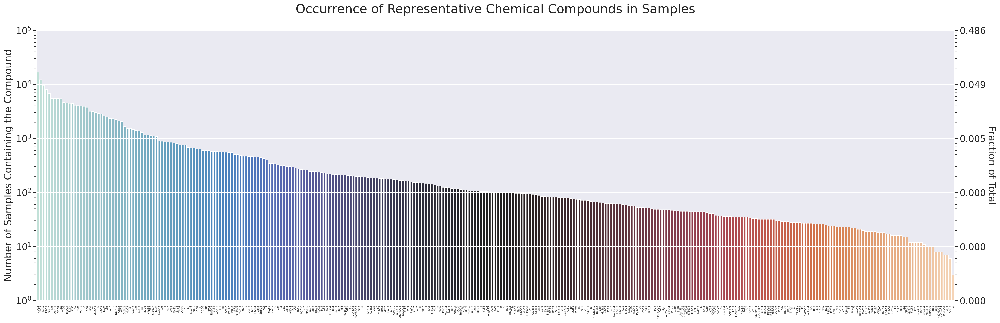

In [23]:
fig = plot_bar_with_fraction(
    data=sorted_compounds_counts,
    title='Occurrence of Representative Chemical Compounds in Samples\n',
    #xlabel='Chemical Compounds',
    ylabel='Number of Samples Containing the Compound',
    palette=first_palette_name,
    figsize=(27, 9),
    font_scale=1.6,
    title_fontsize=24,
    dpi=300,
    rotation=90,
    xtick_fontsize=5
)
plt.show()

/home/diogo-carvalho/miniconda3/envs/GFA/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


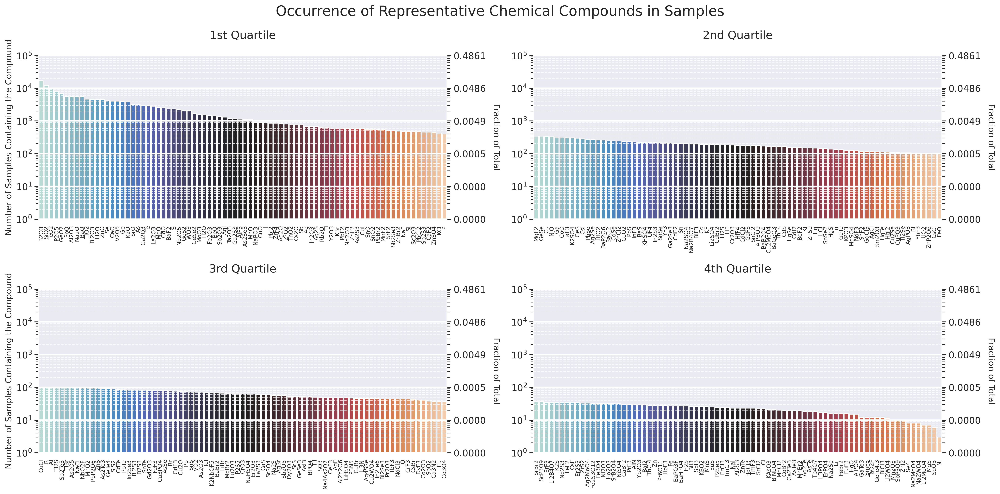

In [24]:
fig = plot_bar_with_fraction(
    data=sorted_compounds_counts,
    title='Occurrence of Representative Chemical Compounds in Samples',
    ylabel='Number of Samples Containing the Compound',
    palette=first_palette_name,
    figsize=(20, 10),
    dpi=300,
    split_plots=True,
    n_splits=4,
    rotation=90,
    xtick_fontsize=8
)
plt.show()

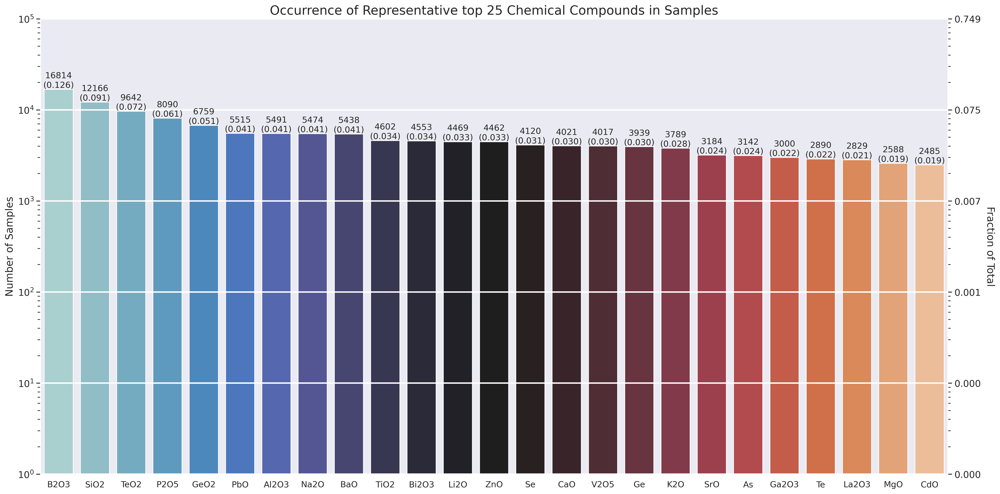

In [25]:
fig = plot_bar_with_fraction(
    data=sorted_compounds_counts,
    title='Occurrence of Representative top 25 Chemical Compounds in Samples',
    ylabel='Number of Samples',
    palette=first_palette_name,
    figsize=(20, 10),
    top_n=25,
    show_values=True,
    rotation=0,
    xtick_fontsize=12
)
plt.show()

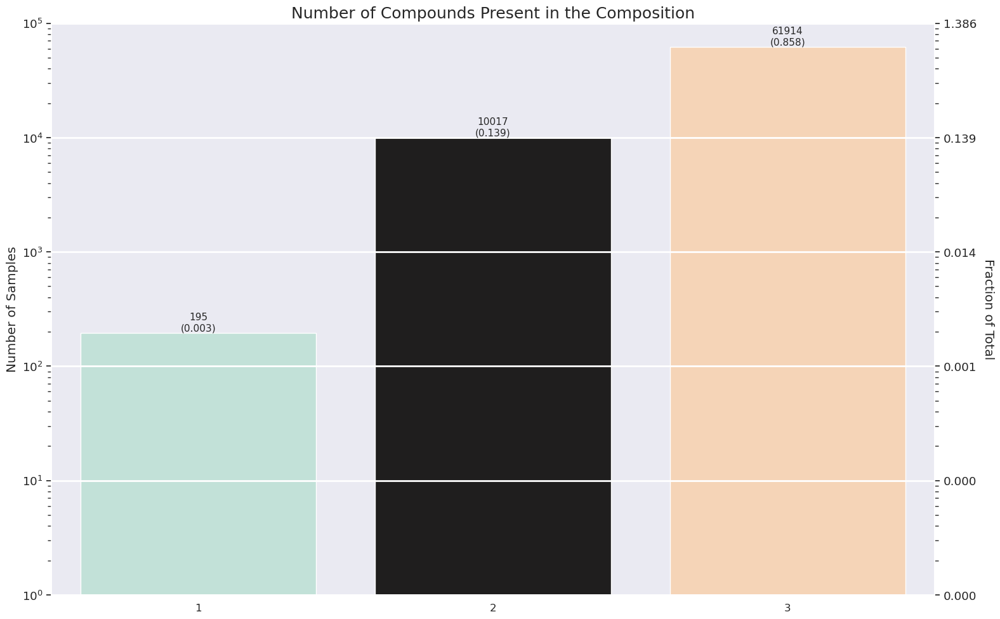

In [26]:
fig = plot_compound_distribution(
    compound_counts=num_compounds_count,
    title='Number of Compounds Present in the Composition',
    palette=first_palette_name,
    show_values=True,
    rotation=0
)
plt.show()

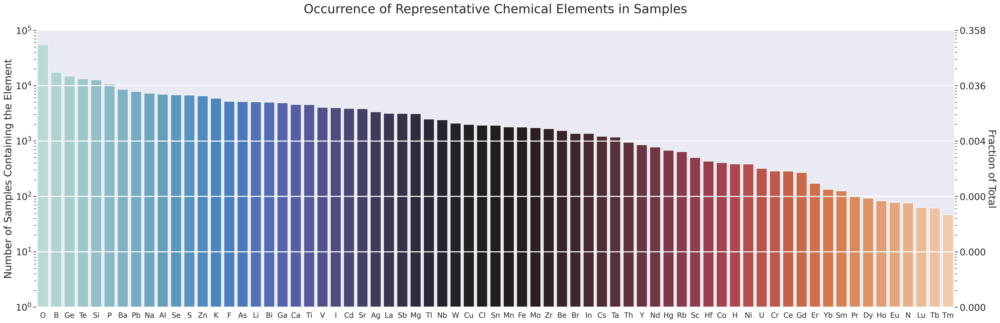

In [27]:
fig = plot_bar_with_fraction(
    data=sorted_elements_counts,
    title='Occurrence of Representative Chemical Elements in Samples\n',
    #xlabel='Chemical Compounds',
    ylabel='Number of Samples Containing the Element',
    palette=first_palette_name,
    figsize=(27, 9),
    font_scale=1.6,
    title_fontsize=24,
    dpi=300,
    rotation=0,
    xtick_fontsize=14
)
plt.show()

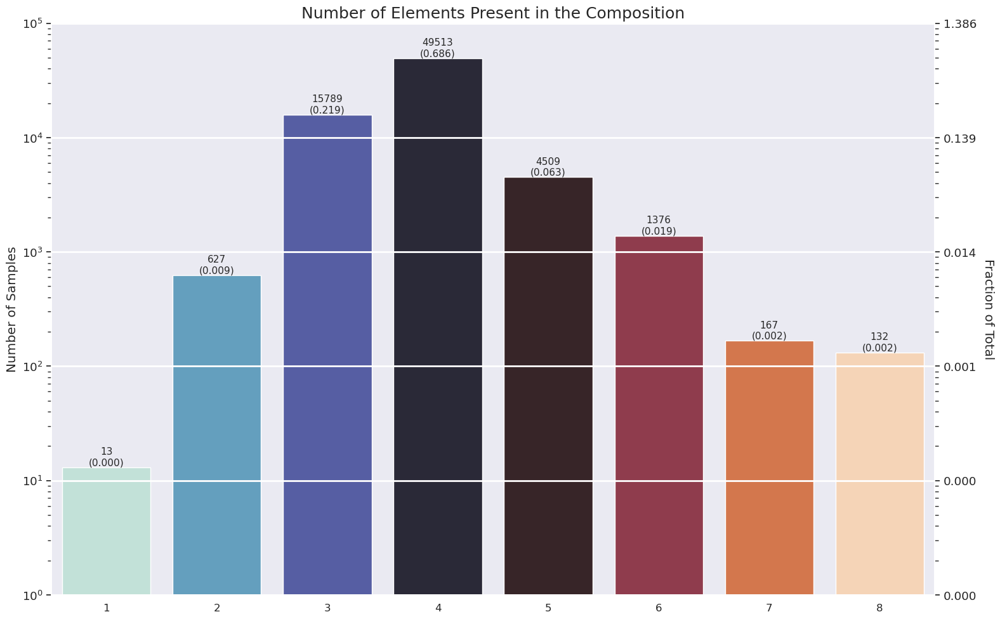

In [28]:
fig = plot_compound_distribution(
    compound_counts=num_elements_count,
    title='Number of Elements Present in the Composition',
    palette=first_palette_name,
    show_values=True,
    rotation=0
)
plt.show()

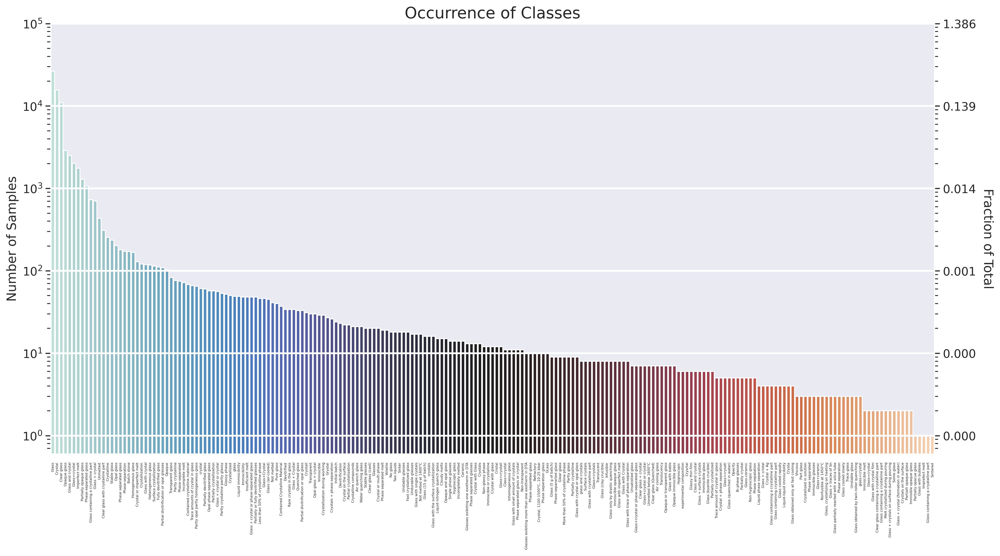

In [29]:
# 5. Class occurrence (full)
fig = plot_bar_with_fraction(
    data=classes_count,
    title='Occurrence of Classes',
    ylabel='Number of Samples',
    palette=first_palette_name,
    figsize=(16, 9),
    dpi=300,
    rotation=90,
    xtick_fontsize=4
)
#plt.savefig('classes.png', dpi=300)
plt.show()

/home/diogo-carvalho/miniconda3/envs/GFA/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


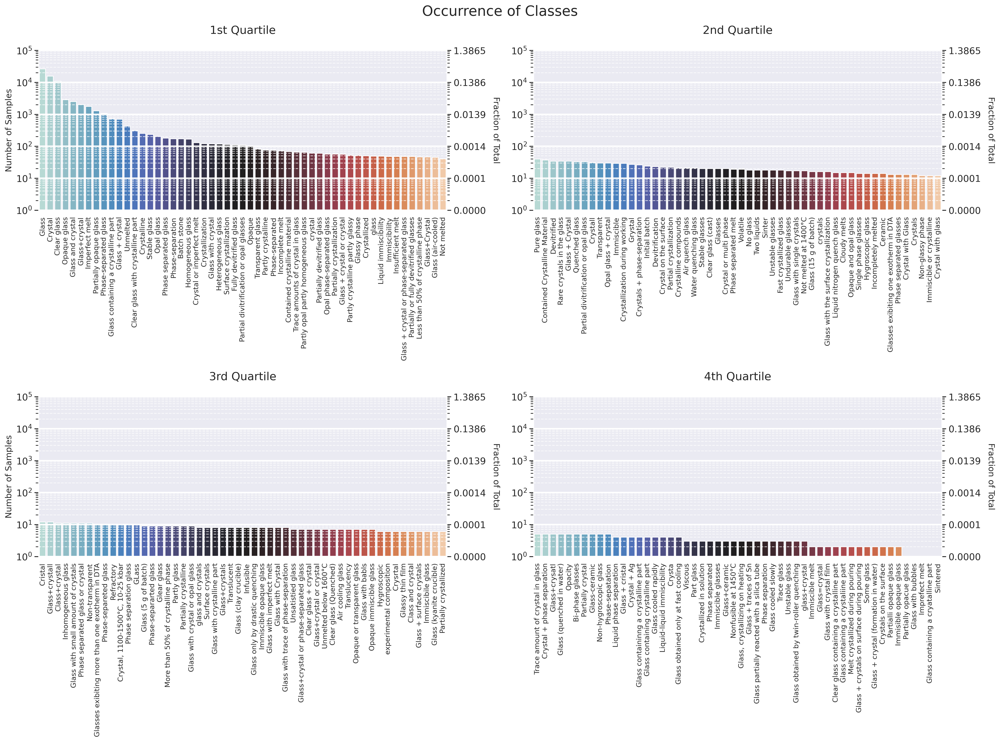

In [30]:
fig = plot_bar_with_fraction(
    data=classes_count,
    title='Occurrence of Classes',
    ylabel='Number of Samples',
    palette=first_palette_name,
    figsize=(20, 15),
    dpi=300,
    split_plots=True,
    n_splits=4,
    rotation=90,
    xtick_fontsize=10
)
plt.show()

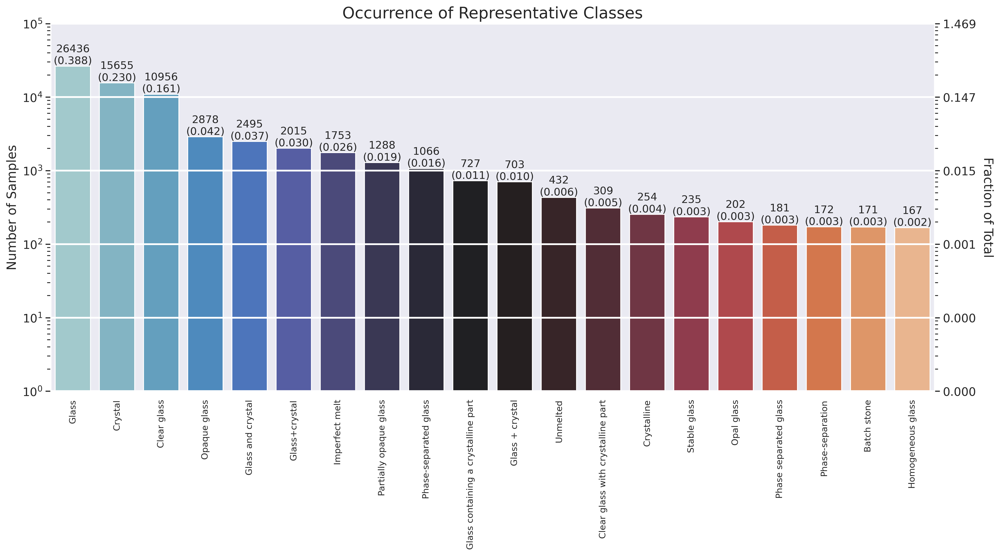

In [31]:
fig = plot_bar_with_fraction(
    data=classes_count,
    title='Occurrence of Representative Classes',
    ylabel='Number of Samples',
    palette=first_palette_name,
    top_n=20,
    show_values=True,
    rotation=90,
    xtick_fontsize=10
)
plt.show()

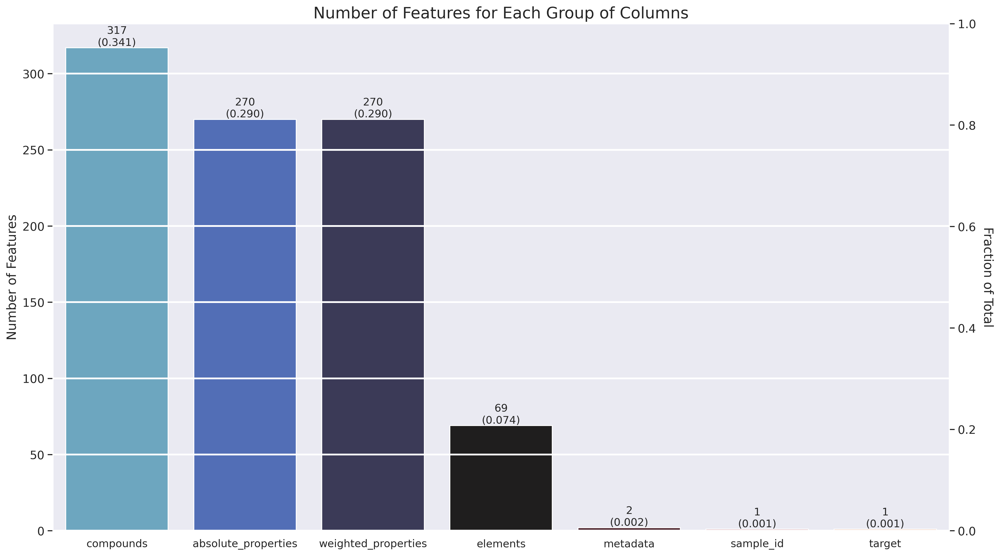

In [32]:
fig = plot_bar_with_fraction(
    data=column_counts,
    title='Number of Features for Each Group of Columns',
    ylabel='Number of Features',
    palette=first_palette_name,
    log_scale=False,
    show_values=True,
    rotation=0,
)
plt.show()

In [33]:
elements_column_ = df_basic_analysis['elements']
compounds_column_ = df_basic_analysis['compounds']
GF_column_ = df_basic_analysis['target']

df_compounds = pd.concat([compounds_column_, GF_column_], axis=1)
df_elements = pd.concat([elements_column_, GF_column_], axis=1)

In [34]:
num_missing_values = df_elements.isnull().sum().sum()
num_negative_values = (((df_elements.drop(["GF"], axis=1)) < 0).sum().sum())
num_duplicated_features = (df_elements.columns.duplicated().sum())

num_examples = df_elements.shape[0]
num_features = df_elements.shape[1] - 1
num_compositions = num_examples - df_elements.iloc[:,:-1].duplicated().sum()
num_compositions_groups = df_elements.iloc[:,:-1].duplicated(keep=False).sum() - df_elements.iloc[:,:-1].duplicated().sum()
num_examples_groups =  df_elements.iloc[:,:-1].duplicated(keep=False).sum()
num_duplicates = df_elements.iloc[:,:].duplicated(keep=False).sum()
num_conflicting_groups = num_examples_groups - num_duplicates
num_examples_not_equal_one = (round((df_compounds.drop(["GF"], axis=1)).sum(axis=1), 7) != 1).sum()

print(f"Number of missing values: {num_missing_values}")
print(f"Number of negative values: {num_negative_values}")
print(f"Number of duplicated features: {num_duplicated_features} (or {num_duplicated_features * 100 / num_features:.2f}%, considering {num_features} total examples)")
print(f"Number of examples that the sum of features doesn't result in 1: {num_examples_not_equal_one} (or {num_examples_not_equal_one * 100 / num_examples:.2f}%, considering {num_examples} total examples) \n")

print(f"Number of compositions with duplicated and/or conflicting examples: {num_compositions_groups} (or {num_compositions_groups * 100 / num_compositions:.2f}%, considering {num_compositions} total compositions).")
print(f"Number of examples with the same compositions: {num_examples_groups} (or {num_examples_groups * 100 / num_examples:.2f}%, considering {num_examples} total examples).")
print(f"Number of duplicated examples: {num_duplicates} (or {num_duplicates * 100 / num_examples:.2f}%)")#, considering {num_examples} total examples).")
print(f"Number of conflicting examples: {num_conflicting_groups} (or {num_conflicting_groups * 100 / num_examples:.2f}%)")#, considering {num_examples} total examples).")

Number of missing values: 0
Number of negative values: 0
Number of duplicated features: 0 (or 0.00%, considering 69 total examples)
Number of examples that the sum of features doesn't result in 1: 0 (or 0.00%, considering 72126 total examples) 

Number of compositions with duplicated and/or conflicting examples: 1549 (or 2.21%, considering 70000 total compositions).
Number of examples with the same compositions: 3675 (or 5.10%, considering 72126 total examples).
Number of duplicated examples: 3063 (or 4.25%)
Number of conflicting examples: 612 (or 0.85%)


# Data Processing

In [35]:
df_translation = pd.read_excel("../data/support/GF_translation.xlsx")
df_translation

,string,count,use_this,GF_SciGlass,liq_liq_sep
0,Unmelted,432,0,0,0
1,Not melted,41,0,0,0
2,Initial batch,24,0,0,0
3,Volatile,19,0,0,0
4,Unstable glasses,18,0,0,0
...,...,...,...,...,...
204,Crystal + Ag,4,0,3,0
205,Crysta,4,0,3,0
206,Crystallized in solution,3,0,3,0
207,Melt crystallized during pouring,2,0,3,0


In [36]:
df_translation_use = df_translation[df_translation["use_this"]==1]

display(df_translation_use)

print(f"There are {sum(df_translation_use['count'])} samples (or {sum(df_translation_use['count']) / sum(df_translation['count']) * 100:.2f}%, considering {sum(df_translation['count'])} total samples)")

,string,count,use_this,GF_SciGlass,liq_liq_sep
21,Glass,26436,1,1,0
22,Clear glass,10956,1,1,0
23,Phase-separated glass,1066,1,1,1
24,Stable glass,235,1,1,0
25,Phase separated glass,181,1,1,1
27,Homogeneous glass,167,1,1,0
29,Transparent glass,83,1,1,0
32,Glassy phase,52,1,1,0
34,glass,49,1,1,0
37,Pure glass,40,1,1,0


There are 55635 samples (or 77.14%, considering 72126 total samples)


In [37]:
df_translation_use.shape

(21, 5)

In [38]:
allowed_labels = df_translation[df_translation['use_this'] == 1]

# string → "Glass"/"Crystal"
label_map = allowed_labels.set_index('string')['GF_SciGlass'].map({1: 'Glass', 3: 'Crystal'}).to_dict()

mask = df_basic_analysis[('target', 'GF')].isin(label_map.keys())
df_binary = df_basic_analysis[mask]

df_binary = df_binary.copy() 
df_binary[('target', 'GF')] = df_binary[('target', 'GF')].map(label_map)
display(df_binary)

compounds                                                        ...  \
             Ag Ag2MoO4 Ag2O Ag2S   Ag2Se Ag2Te Ag4SSe AgBr AgCl  AgF  ...   
0           0.0     0.0  0.0  0.0  0.0000   0.0    0.0  0.0  0.0  0.0  ...   
1           0.0     0.0  0.0  0.0  0.0000   0.0    0.0  0.0  0.0  0.0  ...   
4           0.0     0.0  0.0  0.0  0.0000   0.0    0.0  0.0  0.0  0.0  ...   
5           0.0     0.0  0.0  0.0  0.0000   0.0    0.0  0.0  0.0  0.0  ...   
6           0.0     0.0  0.0  0.0  0.0000   0.0    0.0  0.0  0.0  0.0  ...   
...         ...     ...  ...  ...     ...   ...    ...  ...  ...  ...  ...   
72121       0.0     0.0  0.0  0.0  0.0000   0.0    0.0  0.0  0.0  0.0  ...   
72122       0.0     0.0  0.0  0.0  0.0000   0.0    0.0  0.0  0.0  0.0  ...   
72123       0.0     0.0  0.0  0.0  0.0000   0.0    0.0  0.0  0.0  0.0  ...   
72124       0.0     0.0  0.0  0.0  0.0000   0.0    0.0  0.0  0.0  0.0  ...   
72125       0.0     0.0  0.0  0.0  0.3148   0.0    0.0  0.0  0.0  0.0  ...   

      weighted_properties                                               \
         W|vdw_radius|sum W|zeff|max W|zeff|mean W|zeff|min W|zeff|std   
0              174.533959   2.957922    1.598559   0.141707   1.151780   
1              172.420551   2.973150    1.739684   0.113091   1.200249   
4              174.785746   2.427853    1.223511   0.170554   1.055084   
5              166.986430   3.190395    1.046364   0.072727   1.275694   
6              170.530209   2.610918    0.740836   0.057139   0.886614   
...                   ...        ...         ...        ...        ...   
72121          171.581782   2.791529    1.232472   0.239197   1.004672   
72122          170.617192   2.749651    1.027688   0.150078   1.018688   
72123          165.248142   3.233891    1.113186   0.196258   1.234545   
72124          175.705921   2.621800    1.237246   0.138465   0.978688   
72125          199.462612   3.855358    1.483646   0.069534   1.429727   

                      metadata              sample_id   target  
      W|zeff|sum num_compounds num_elements       Kod       GF  
0       4.795677             2            3     21883    Glass  
1       5.219052             2            3     21472    Glass  
4       4.894043             3            4     24639  Crystal  
5       4.185455             3            4     22412    Glass  
6       4.445015             3            6     28339    Glass  
...          ...           ...          ...       ...      ...  
72121   4.929888             3            4     22220  Crystal  
72122   4.110753             3            4     22603  Crystal  
72123   4.452745             3            4     33008    Glass  
72124   4.948985             3            4     22175    Glass  
72125   5.934584             3            4     37056  Crystal  

[55635 rows x 930 columns]

In [39]:
elements_df = df_binary["elements"].round(3)
labels = df_binary[("target", "GF")]
df_check = pd.concat([elements_df, labels], axis=1)

grouped = df_check.groupby(list(elements_df.columns))

# Initialize containers and counters
total_instances = len(df_check)
unique_compositions = grouped.ngroups
duplicate_instances = 0
conflicting_compositions = 0
conflicting_instances = 0
non_unimodal_instances = 0
excluded_by_duplicates = 0
excluded_by_conflicts = 0
excluded_by_non_unimodal = 0
retained_instances = 0

multi_instance_composition_instances = 0
multi_instance_compositions = 0
excluded_compositions = 0

valid_rows = []

# Iterate over each group
for i, (_, group) in enumerate(grouped):
    if i % 1000 == 0:
        print(f"{i} / {unique_compositions}", end='\r')
    
    n_instances = len(group)
    
    if n_instances > 1:
        multi_instance_composition_instances += n_instances
        multi_instance_compositions += 1

    label_counts = group[("target", "GF")].value_counts()

    if len(label_counts) == 1:
        # No label conflict (all labels the same)
        valid_rows.append(group.iloc[0])
        retained_instances += 1
        excluded_by_duplicates += (n_instances - 1)  # keep only one
        duplicate_instances += (n_instances - 1)
    elif label_counts.iloc[0] > label_counts.iloc[1]:
        # Unimodal case (majority label)
        majority_label = label_counts.idxmax()
        group_majority = group[group[("target", "GF")] == majority_label]
        valid_rows.append(group_majority.iloc[0])
        retained_instances += 1
        excluded_by_duplicates += (len(group_majority) - 1)
        excluded_by_conflicts += (n_instances - len(group_majority))
        duplicate_instances += (len(group_majority) - 1)
        conflicting_instances += (n_instances - len(group_majority))
    else:
        # Multimodal (no dominant label)
        conflicting_compositions += 1
        conflicting_instances += n_instances
        excluded_by_non_unimodal += n_instances
        excluded_compositions += 1

df_cleaned = pd.DataFrame(valid_rows)
df_unimodal = df_binary.loc[df_cleaned.index].reset_index(drop=True)

# df_unimodal.to_excel("./unimodal_dataset.xlsx", index=False)

# Final stats
print(f"Total number of instances: {total_instances}")
print(f"Total number of compositions: {unique_compositions}")
print(f"Number of instances in compositions with multiples instances: {multi_instance_composition_instances} ({multi_instance_composition_instances / total_instances * 100:.2f}%)")
print(f"Number of duplicate instances (same label): {duplicate_instances} ({duplicate_instances / total_instances * 100:.2f}%)")
print(f"Number of conflicting instances (different labels): {conflicting_instances} ({conflicting_instances / total_instances * 100:.2f}%)\n")
print(f"Compositions with multiples instances: {multi_instance_compositions} ({multi_instance_compositions / unique_compositions * 100:.2f}%)\n")

print(f"Instances excluded as duplicates: {excluded_by_duplicates} ({excluded_by_duplicates / total_instances * 100:.2f}%)")
print(f"Instances excluded due to conflicting labels: {excluded_by_conflicts} ({excluded_by_conflicts / total_instances * 100:.2f}%)")
print(f"Instances excluded due to non-unimodal group: {excluded_by_non_unimodal} ({excluded_by_non_unimodal / total_instances * 100:.2f}%)")
print(f"Compositions excluded due to conflicts: {excluded_compositions} ({excluded_compositions / unique_compositions * 100:.2f}%)\n")

print(f"Compositions retained: {unique_compositions - excluded_compositions} ({(unique_compositions - excluded_compositions) / unique_compositions * 100:.2f}%)")
print(f"Final number of instances retained: {retained_instances} ({retained_instances / total_instances * 100:.2f}%)")

Total number of instances: 55635
Total number of compositions: 51763
Number of instances in compositions with multiples instances: 6165 (11.08%)
Number of duplicate instances (same label): 3591 (6.45%)
Number of conflicting instances (different labels): 422 (0.76%)

Compositions with multiples instances: 2293 (4.43%)

Instances excluded as duplicates: 3591 (6.45%)
Instances excluded due to conflicting labels: 118 (0.21%)
Instances excluded due to non-unimodal group: 304 (0.55%)
Compositions excluded due to conflicts: 141 (0.27%)

Compositions retained: 51622 (99.73%)
Final number of instances retained: 51622 (92.79%)


In [40]:
elements_df = df_binary["elements"].round(3)
labels = df_binary[("target", "GF")]
df_check = pd.concat([elements_df, labels], axis=1)

grouped = df_check.groupby(list(elements_df.columns))

# Initialize containers and counters
total_instances = len(df_check)
unique_compositions = grouped.ngroups
duplicate_instances = 0
conflicting_compositions = 0
conflicting_instances = 0
non_unimodal_instances = 0
excluded_by_duplicates = 0
excluded_by_conflicts = 0
excluded_by_non_unimodal = 0
retained_instances = 0

multi_instance_composition_instances = 0
multi_instance_compositions = 0
excluded_compositions = 0

valid_rows = []

# Iterate over each group
for i, (_, group) in enumerate(grouped):
    if i % 1000 == 0:
        print(f"{i} / {unique_compositions}", end='\r')
    
    n_instances = len(group)
    
    if n_instances > 1:
        multi_instance_composition_instances += n_instances
        multi_instance_compositions += 1

    label_counts = group[("target", "GF")].value_counts()

    if len(label_counts) == 1:
        # No label conflict (all labels the same)
        valid_rows.append(group.iloc[0])
        retained_instances += 1
        excluded_by_duplicates += (n_instances - 1)  # keep only one
        duplicate_instances += (n_instances - 1)
    elif label_counts.iloc[0] > label_counts.iloc[1]:
        # Unimodal case (majority label)
        majority_label = label_counts.idxmax()
        group_majority = group[group[("target", "GF")] == majority_label]
        valid_rows.append(group_majority.iloc[0])
        retained_instances += 1
        excluded_by_duplicates += (len(group_majority) - 1)
        excluded_by_conflicts += (n_instances - len(group_majority))
        duplicate_instances += (len(group_majority) - 1)
        conflicting_instances += (n_instances - len(group_majority))
    else:
        # Multimodal (no dominant label)
        conflicting_compositions += 1
        conflicting_instances += n_instances
        excluded_by_non_unimodal += n_instances
        excluded_compositions += 1

df_cleaned = pd.DataFrame(valid_rows)
df_unimodal = df_binary.loc[df_cleaned.index].reset_index(drop=True)

# df_unimodal.to_excel("./unimodal_dataset.xlsx", index=False)

# Final stats
print(f"Total number of instances: {total_instances}")
print(f"Total number of compositions: {unique_compositions}")
print(f"Number of instances in compositions with multiples instances: {multi_instance_composition_instances} ({multi_instance_composition_instances / total_instances * 100:.2f}%)")
print(f"Number of duplicate instances (same label): {duplicate_instances} ({duplicate_instances / total_instances * 100:.2f}%)")
print(f"Number of conflicting instances (different labels): {conflicting_instances} ({conflicting_instances / total_instances * 100:.2f}%)\n")
print(f"Compositions with multiples instances: {multi_instance_compositions} ({multi_instance_compositions / unique_compositions * 100:.2f}%)\n")

print(f"Instances excluded as duplicates: {excluded_by_duplicates} ({excluded_by_duplicates / total_instances * 100:.2f}%)")
print(f"Instances excluded due to conflicting labels: {excluded_by_conflicts} ({excluded_by_conflicts / total_instances * 100:.2f}%)")
print(f"Instances excluded due to non-unimodal group: {excluded_by_non_unimodal} ({excluded_by_non_unimodal / total_instances * 100:.2f}%)")
print(f"Compositions excluded due to conflicts: {excluded_compositions} ({excluded_compositions / unique_compositions * 100:.2f}%)\n")

print(f"Compositions retained: {unique_compositions - excluded_compositions} ({(unique_compositions - excluded_compositions) / unique_compositions * 100:.2f}%)")
print(f"Final number of instances retained: {retained_instances} ({retained_instances / total_instances * 100:.2f}%)")

Total number of instances: 55635
Total number of compositions: 51763
Number of instances in compositions with multiples instances: 6165 (11.08%)
Number of duplicate instances (same label): 3591 (6.45%)
Number of conflicting instances (different labels): 422 (0.76%)

Compositions with multiples instances: 2293 (4.43%)

Instances excluded as duplicates: 3591 (6.45%)
Instances excluded due to conflicting labels: 118 (0.21%)
Instances excluded due to non-unimodal group: 304 (0.55%)
Compositions excluded due to conflicts: 141 (0.27%)

Compositions retained: 51622 (99.73%)
Final number of instances retained: 51622 (92.79%)


In [41]:
display(df_unimodal)
print(f"There are {df_unimodal.shape[0]} instances (or {df_unimodal.shape[0] / sum(df_translation['count']) * 100:.2f}%, considering {sum(df_translation['count'])} total instances)")

# df_unimodal.to_csv("./../data/processed/GF_binary_feature_engineering.zip")

compounds                                                        ...  \
             Ag Ag2MoO4   Ag2O Ag2S Ag2Se Ag2Te Ag4SSe AgBr AgCl  AgF  ...   
0      0.000000     0.0  0.000  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
1      0.000000     0.0  0.000  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
2      0.000000     0.0  0.000  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
3      0.000000     0.0  0.000  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
4      0.000000     0.0  0.000  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
...         ...     ...    ...  ...   ...   ...    ...  ...  ...  ...  ...   
51617  0.546000     0.0  0.000  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
51618  0.000000     0.0  0.906  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
51619  0.598000     0.0  0.000  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
51620  0.602000     0.0  0.000  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
51621  0.666334     0.0  0.000  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   

      weighted_properties                                               \
         W|vdw_radius|sum W|zeff|max W|zeff|mean W|zeff|min W|zeff|std   
0              201.635547   3.916705    3.049466   2.182227   0.867239   
1              201.994000   4.165830    3.084415   2.003000   1.081415   
2              205.997900   6.949305    3.474968   0.000630   3.474338   
3              202.272600   4.219345    2.057202   0.059760   1.702132   
4              202.642200   4.477190    2.081345   0.059345   1.822847   
...                   ...        ...         ...        ...        ...   
51617          197.701000   2.020200    1.542083   0.976500   0.430554   
51618          188.463096   2.125973    1.011363   0.078107   0.921248   
51619          199.283000   2.212600    1.510050   0.938700   0.528277   
51620          198.672000   2.227400    1.466067   0.012600   1.028144   
51621          200.656344   2.465435    2.141958   1.818482   0.323477   

                      metadata              sample_id   target  
      W|zeff|sum num_compounds num_elements       Kod       GF  
0       6.098932             2            2     26356  Crystal  
1       6.168830             2            2     26356  Crystal  
2       6.949935             2            2     27653  Crystal  
3       6.171605             3            3     26356  Crystal  
4       6.244035             3            3     26356  Crystal  
...          ...           ...          ...       ...      ...  
51617   4.626250             3            3     27768  Crystal  
51618   4.045453             3            4     36491  Crystal  
51619   4.530150             3            3     27768  Crystal  
51620   4.398200             3            3     27768  Crystal  
51621   4.283916             2            2     27768  Crystal  

[51622 rows x 930 columns]

There are 51622 instances (or 71.57%, considering 72126 total instances)


In [42]:
elements_column_ = df_unimodal['elements']
GF_column_ = df_unimodal['target']

df_elements = pd.concat([elements_column_, GF_column_], axis=1)

num_missing_values = df_elements.isnull().sum().sum()
num_negative_values = (((df_elements.drop(["GF"], axis=1)) < 0).sum().sum())
num_duplicated_features = (df_elements.columns.duplicated().sum())

num_examples = df_elements.shape[0]
num_features = df_elements.shape[1] - 1
num_compositions = num_examples - df_elements.iloc[:,:-1].duplicated().sum()
num_compositions_groups = df_elements.iloc[:,:-1].duplicated(keep=False).sum() - df_elements.iloc[:,:-1].duplicated().sum()
num_examples_groups =  df_elements.iloc[:,:-1].duplicated(keep=False).sum()
num_duplicates = df_elements.iloc[:,:].duplicated(keep=False).sum()
num_conflicting_groups = num_examples_groups - num_duplicates
num_examples_not_equal_one = (round((df_compounds.drop(["GF"], axis=1)).sum(axis=1), 7) != 1).sum()

print(f"Number of missing values: {num_missing_values}")
print(f"Number of negative values: {num_negative_values}")
print(f"Number of duplicated features: {num_duplicated_features} (or {num_duplicated_features * 100 / num_features:.2f}%, considering {num_features} total examples)")
print(f"Number of examples that the sum of features doesn't result in 1: {num_examples_not_equal_one} (or {num_examples_not_equal_one * 100 / num_examples:.2f}%, considering {num_examples} total examples) \n")

print(f"Number of compositions with duplicated and/or conflicting examples: {num_compositions_groups} (or {num_compositions_groups * 100 / num_compositions:.2f}%, considering {num_compositions} total compositions).")
print(f"Number of examples with the same compositions: {num_examples_groups} (or {num_examples_groups * 100 / num_examples:.2f}%, considering {num_examples} total examples).")
print(f"Number of duplicated examples: {num_duplicates} (or {num_duplicates * 100 / num_examples:.2f}%)")#, considering {num_examples} total examples).")
print(f"Number of conflicting examples: {num_conflicting_groups} (or {num_conflicting_groups * 100 / num_examples:.2f}%)")#, considering {num_examples} total examples).")

Number of missing values: 0
Number of negative values: 0
Number of duplicated features: 0 (or 0.00%, considering 69 total examples)
Number of examples that the sum of features doesn't result in 1: 0 (or 0.00%, considering 51622 total examples) 

Number of compositions with duplicated and/or conflicting examples: 0 (or 0.00%, considering 51622 total compositions).
Number of examples with the same compositions: 0 (or 0.00%, considering 51622 total examples).
Number of duplicated examples: 0 (or 0.00%)
Number of conflicting examples: 0 (or 0.00%)


In [43]:
constant_columns = df_unimodal.columns[df_unimodal.nunique(dropna=False) <= 1]

df_unimodal = df_unimodal.drop(columns=constant_columns)

print(f"Number of constant columns: {len(constant_columns)}")
print(f"Constant columns: {constant_columns.tolist()}\n")

print(f"Dropped constant columns.")

Number of constant columns: 15
Constant columns: [('compounds', 'Li2MoO4'), ('compounds', 'Li2WO4'), ('compounds', 'Na2MoO4'), ('compounds', 'Na2WO4'), ('absolute_properties', 'A|GSmagmom|min'), ('absolute_properties', 'A|NdUnfilled|min'), ('absolute_properties', 'A|NfUnfilled|min'), ('absolute_properties', 'A|NfValence|min'), ('absolute_properties', 'A|NsUnfilled|min'), ('absolute_properties', 'A|NsValence|max'), ('weighted_properties', 'W|GSmagmom|min'), ('weighted_properties', 'W|NdUnfilled|min'), ('weighted_properties', 'W|NfUnfilled|min'), ('weighted_properties', 'W|NfValence|min'), ('weighted_properties', 'W|NsUnfilled|min')]

Dropped constant columns.


In [44]:
df_unimodal

compounds                                                        ...  \
             Ag Ag2MoO4   Ag2O Ag2S Ag2Se Ag2Te Ag4SSe AgBr AgCl  AgF  ...   
0      0.000000     0.0  0.000  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
1      0.000000     0.0  0.000  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
2      0.000000     0.0  0.000  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
3      0.000000     0.0  0.000  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
4      0.000000     0.0  0.000  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
...         ...     ...    ...  ...   ...   ...    ...  ...  ...  ...  ...   
51617  0.546000     0.0  0.000  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
51618  0.000000     0.0  0.906  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
51619  0.598000     0.0  0.000  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
51620  0.602000     0.0  0.000  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
51621  0.666334     0.0  0.000  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   

      weighted_properties                                               \
         W|vdw_radius|sum W|zeff|max W|zeff|mean W|zeff|min W|zeff|std   
0              201.635547   3.916705    3.049466   2.182227   0.867239   
1              201.994000   4.165830    3.084415   2.003000   1.081415   
2              205.997900   6.949305    3.474968   0.000630   3.474338   
3              202.272600   4.219345    2.057202   0.059760   1.702132   
4              202.642200   4.477190    2.081345   0.059345   1.822847   
...                   ...        ...         ...        ...        ...   
51617          197.701000   2.020200    1.542083   0.976500   0.430554   
51618          188.463096   2.125973    1.011363   0.078107   0.921248   
51619          199.283000   2.212600    1.510050   0.938700   0.528277   
51620          198.672000   2.227400    1.466067   0.012600   1.028144   
51621          200.656344   2.465435    2.141958   1.818482   0.323477   

                      metadata              sample_id   target  
      W|zeff|sum num_compounds num_elements       Kod       GF  
0       6.098932             2            2     26356  Crystal  
1       6.168830             2            2     26356  Crystal  
2       6.949935             2            2     27653  Crystal  
3       6.171605             3            3     26356  Crystal  
4       6.244035             3            3     26356  Crystal  
...          ...           ...          ...       ...      ...  
51617   4.626250             3            3     27768  Crystal  
51618   4.045453             3            4     36491  Crystal  
51619   4.530150             3            3     27768  Crystal  
51620   4.398200             3            3     27768  Crystal  
51621   4.283916             2            2     27768  Crystal  

[51622 rows x 915 columns]

## Data Export

In [46]:
df_unimodal.to_pickle("./../data/interim/GF_binary_feature_engineering.pkl.zip")

In [47]:
df_unimodal_32 = optimize_dtypes(df_unimodal.copy())
df_unimodal_32.to_pickle("./../data/interim/GF_binary_feature_engineering_32bit.pkl.zip")

# Data Analysis (Processed Dataset)

In [ ]:
display(df_unimodal)
print(df_unimodal.columns.levels[0].tolist())

compounds                                                        ...  \
             Ag Ag2MoO4   Ag2O Ag2S Ag2Se Ag2Te Ag4SSe AgBr AgCl  AgF  ...   
0      0.000000     0.0  0.000  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
1      0.000000     0.0  0.000  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
2      0.000000     0.0  0.000  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
3      0.000000     0.0  0.000  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
4      0.000000     0.0  0.000  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
...         ...     ...    ...  ...   ...   ...    ...  ...  ...  ...  ...   
51617  0.546000     0.0  0.000  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
51618  0.000000     0.0  0.906  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
51619  0.598000     0.0  0.000  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
51620  0.602000     0.0  0.000  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   
51621  0.666334     0.0  0.000  0.0   0.0   0.0    0.0  0.0  0.0  0.0  ...   

      weighted_properties                                               \
         W|vdw_radius|sum W|zeff|max W|zeff|mean W|zeff|min W|zeff|std   
0              201.635547   3.916705    3.049466   2.182227   0.867239   
1              201.994000   4.165830    3.084415   2.003000   1.081415   
2              205.997900   6.949305    3.474968   0.000630   3.474338   
3              202.272600   4.219345    2.057202   0.059760   1.702132   
4              202.642200   4.477190    2.081345   0.059345   1.822847   
...                   ...        ...         ...        ...        ...   
51617          197.701000   2.020200    1.542083   0.976500   0.430554   
51618          188.463096   2.125973    1.011363   0.078107   0.921248   
51619          199.283000   2.212600    1.510050   0.938700   0.528277   
51620          198.672000   2.227400    1.466067   0.012600   1.028144   
51621          200.656344   2.465435    2.141958   1.818482   0.323477   

                      metadata              sample_id   target  
      W|zeff|sum num_compounds num_elements       Kod       GF  
0       6.098932             2            2     26356  Crystal  
1       6.168830             2            2     26356  Crystal  
2       6.949935             2            2     27653  Crystal  
3       6.171605             3            3     26356  Crystal  
4       6.244035             3            3     26356  Crystal  
...          ...           ...          ...       ...      ...  
51617   4.626250             3            3     27768  Crystal  
51618   4.045453             3            4     36491  Crystal  
51619   4.530150             3            3     27768  Crystal  
51620   4.398200             3            3     27768  Crystal  
51621   4.283916             2            2     27768  Crystal  

[51622 rows x 915 columns]

['absolute_properties', 'compounds', 'elements', 'metadata', 'sample_id', 'target', 'weighted_properties']


In [ ]:
column_levels = df_unimodal.columns.get_level_values(0)
column_counts = column_levels.value_counts()

print(column_counts)

compounds              313
weighted_properties    265
absolute_properties    264
elements                69
metadata                 2
sample_id                1
target                   1
Name: count, dtype: int64


In [ ]:
single_element_df = df_unimodal[df_unimodal['metadata', 'num_elements'] == 1]

compounds = single_element_df.loc[:, 'compounds']
elements = single_element_df.loc[:, 'elements']
target = single_element_df.loc[:, 'target'] 

compounds_nonzero = compounds.loc[:, (compounds != 0.0).any()]
elements_nonzero = elements.loc[:, (elements != 0.0).any()]

result = pd.concat([compounds_nonzero, elements_nonzero, target], axis=1)

display(result)

,Ge,Se,Ge,Se,GF
131,0.0,1.0,0.0,1.0,Glass
14284,1.0,0.0,1.0,0.0,Crystal


In [ ]:
compounds_counts = (df_unimodal['compounds'].round(4) != 0).sum()
sorted_compounds_counts = compounds_counts.sort_values(ascending=False)
print(f"There are {sum(compounds_counts)} compounds (non null)")

elements_counts = (df_unimodal['elements'].round(4) != 0).sum()
sorted_elements_counts = elements_counts.sort_values(ascending=False)
print(f"There are {sum(elements_counts)} elements (non null)")

classes_count = df_unimodal[('target', 'GF')].value_counts()
print(f"There are {len(classes_count)} classes: {classes_count.index.to_list()}")

num_compounds_count = df_unimodal[('metadata', 'num_compounds')].value_counts().sort_index()
num_elements_count = df_unimodal[('metadata', 'num_elements')].value_counts().sort_index()

There are 149538 compounds (non null)
There are 201940 elements (non null)
There are 2 classes: ['Glass', 'Crystal']


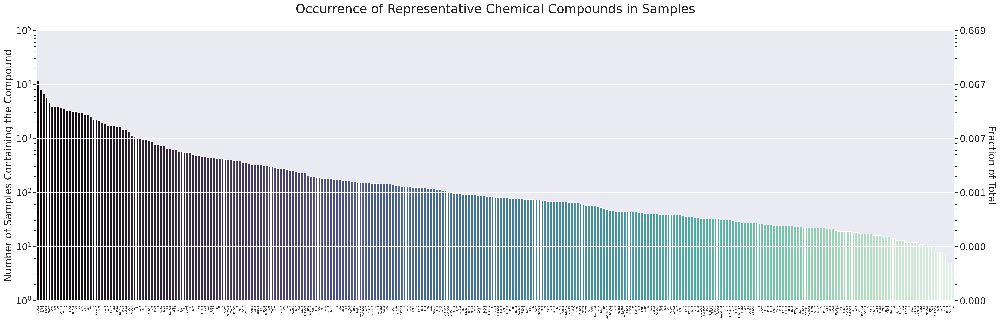

In [ ]:
fig = plot_bar_with_fraction(
    data=sorted_compounds_counts,
    title='Occurrence of Representative Chemical Compounds in Samples\n',
    #xlabel='Chemical Compounds',
    ylabel='Number of Samples Containing the Compound',
    palette=unimodal_palette_name,
    figsize=(27, 9),
    font_scale=1.6,
    title_fontsize=24,
    dpi=300,
    rotation=90,
    xtick_fontsize=5
)
plt.show()

/home/diogo-carvalho/miniconda3/envs/GFA/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


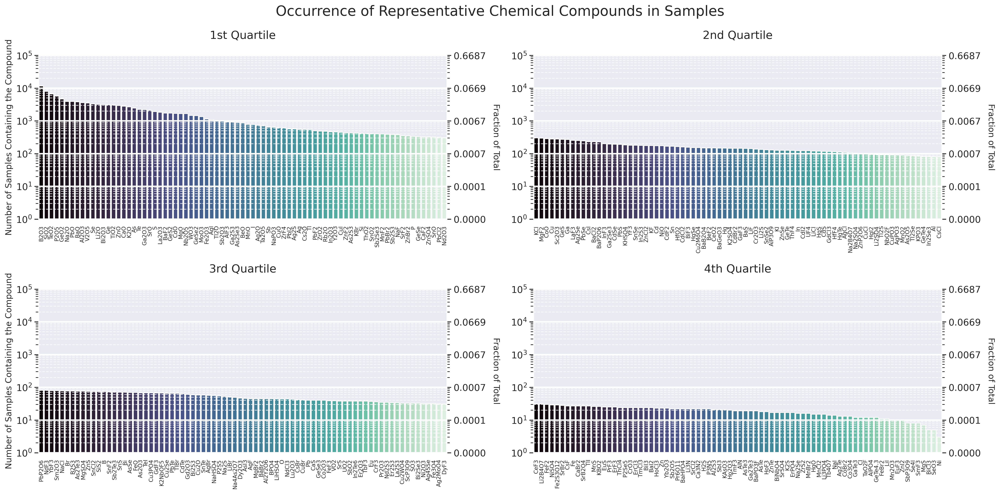

In [ ]:
fig = plot_bar_with_fraction(
    data=sorted_compounds_counts,
    title='Occurrence of Representative Chemical Compounds in Samples',
    ylabel='Number of Samples Containing the Compound',
    palette=unimodal_palette_name,
    figsize=(20, 10),
    dpi=300,
    split_plots=True,
    n_splits=4,
    rotation=90,
    xtick_fontsize=8
)
plt.show()

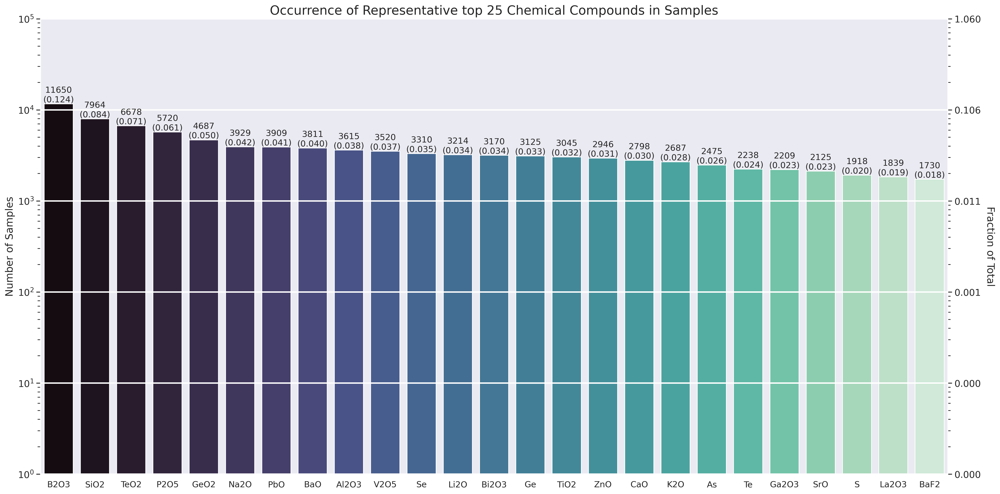

In [ ]:
fig = plot_bar_with_fraction(
    data=sorted_compounds_counts,
    title='Occurrence of Representative top 25 Chemical Compounds in Samples',
    ylabel='Number of Samples',
    palette=unimodal_palette_name,
    figsize=(20, 10),
    top_n=25,
    show_values=True,
    rotation=0,
    xtick_fontsize=12
)
plt.show()

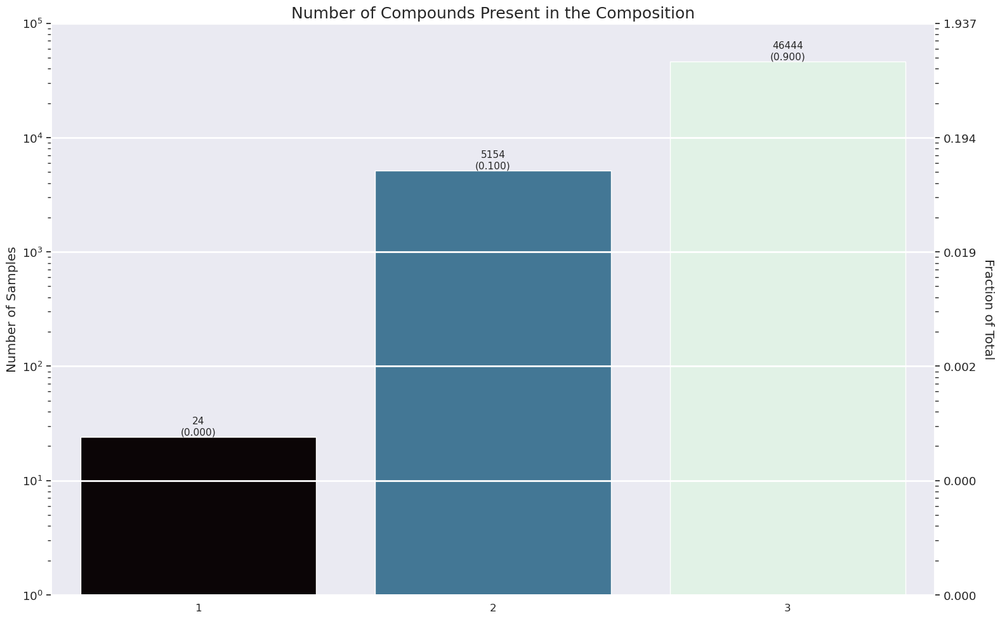

In [ ]:
fig = plot_compound_distribution(
    compound_counts=num_compounds_count,
    title='Number of Compounds Present in the Composition',
    palette=unimodal_palette_name,
    show_values=True,
    rotation=0
)
plt.show()

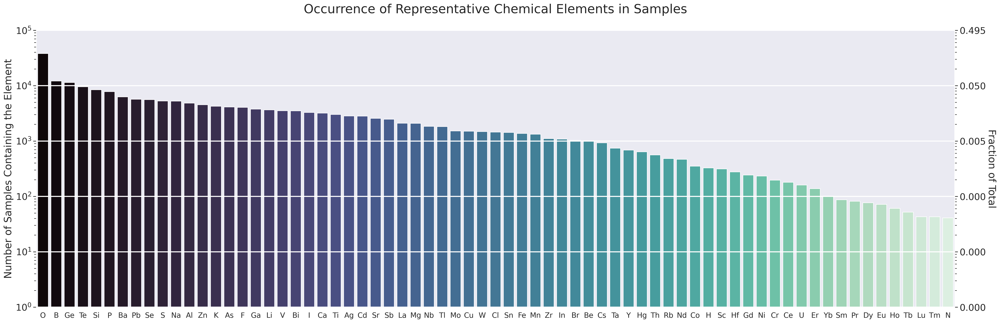

In [ ]:
fig = plot_bar_with_fraction(
    data=sorted_elements_counts,
    title='Occurrence of Representative Chemical Elements in Samples\n',
    #xlabel='Chemical Compounds',
    ylabel='Number of Samples Containing the Element',
    palette=unimodal_palette_name,
    figsize=(27, 9),
    font_scale=1.6,
    title_fontsize=24,
    dpi=300,
    rotation=0,
    xtick_fontsize=14
)
plt.show()

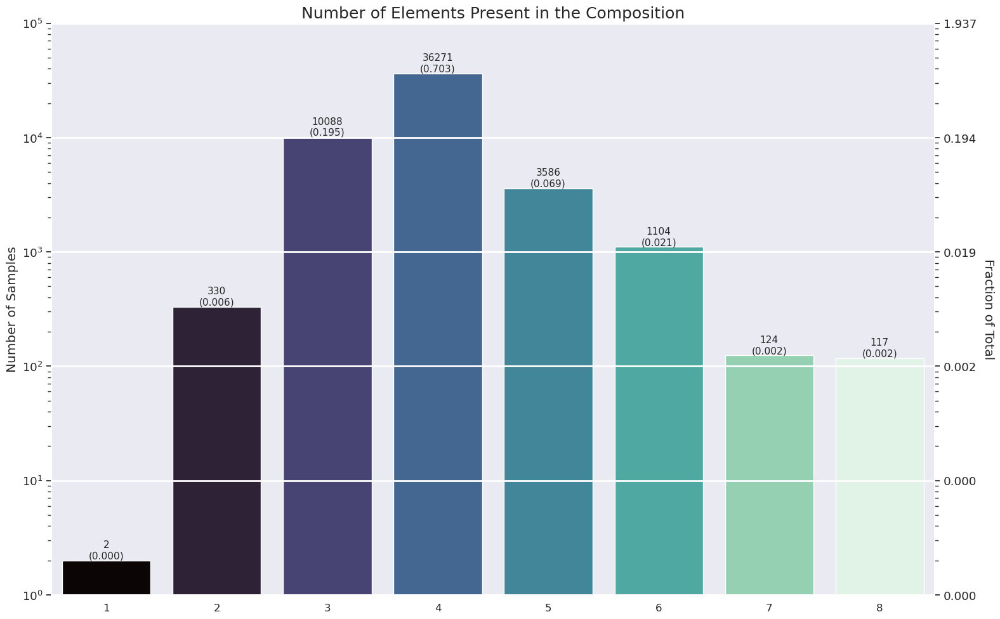

In [ ]:
fig = plot_compound_distribution(
    compound_counts=num_elements_count,
    title='Number of Elements Present in the Composition',
    palette=unimodal_palette_name,
    show_values=True,
    rotation=0
)
plt.show()

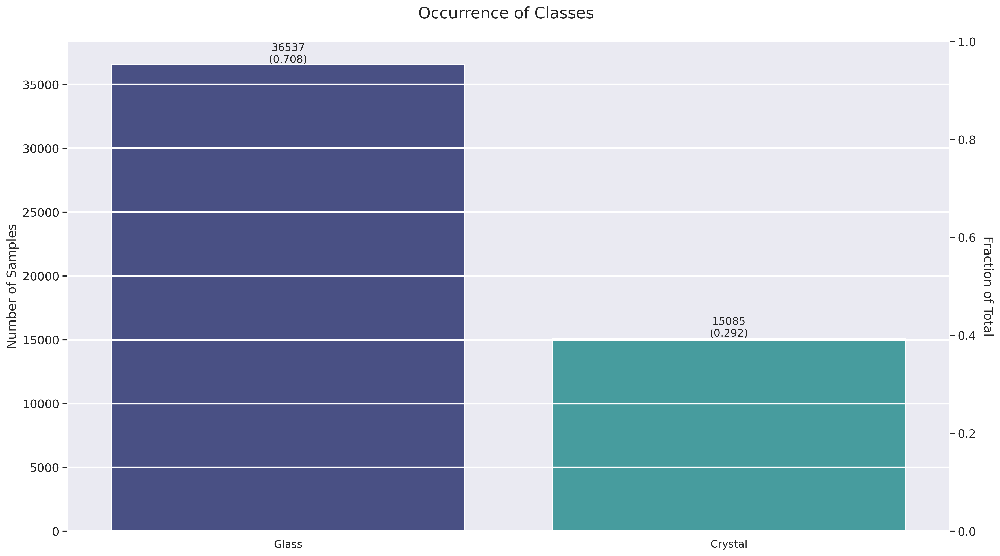

In [ ]:
# 5. Class occurrence (full)
fig = plot_bar_with_fraction(
    data=classes_count,
    title='Occurrence of Classes \n',
    ylabel='Number of Samples',
    palette=unimodal_palette_name,
    log_scale=False,
    figsize=(16, 9),
    dpi=300,
    show_values=True,
    rotation=0
)
#plt.savefig('classes.png', dpi=300)
plt.show()

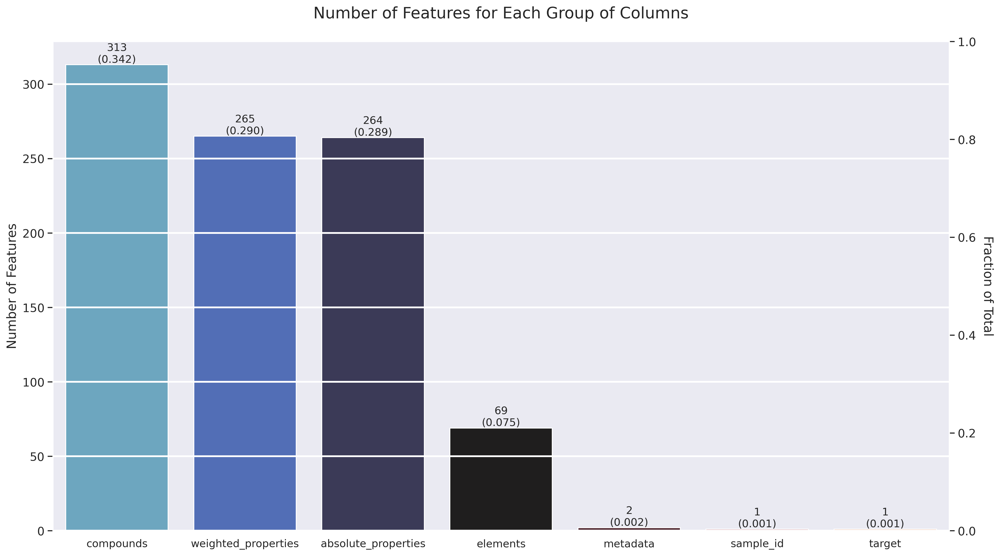

In [ ]:
fig = plot_bar_with_fraction(
    data=column_counts,
    title='Number of Features for Each Group of Columns\n',
    ylabel='Number of Features',
    palette=first_palette_name,
    log_scale=False,
    show_values=True,
    rotation=0,
)
plt.show()